### **1. CHUẨN BỊ DỮ LIỆU**

In [4]:
import pandas as pd
import time
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import gdown
import os
import warnings
import underthesea
from datetime import datetime
from underthesea import word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from datasets import load_dataset
from IPython.display import Markdown, display

warnings.filterwarnings('ignore')

In [5]:
dataset_dir = '../dataset'
os.makedirs(dataset_dir, exist_ok=True)

# Danh sách ID từ link Google Drive gốc của nhóm tác giả
file_ids = {
    'train_sentences.txt': '1nzak5OkrheRV1ltOGCXkT671bmjODLhP',
    'train_sentiments.txt': '1ye-gOZIBqXdKOoi_YxvpT6FeRNmViPPv',
    'train_topics.txt': '14MuDtwMnNOcr4z_8KdpxprjbwaQ7lJ_C',
    'val_sentences.txt': '1sMJSR3oRfPc3fe1gK-V3W5F24tov_517',
    'val_sentiments.txt': '1GiY1AOp41dLXIIkgES4422AuDwmbUseL',
    'val_topics.txt': '1DwLgDEaFWQe8mOd7EpF-xqMEbDLfdT-W',
    'test_sentences.txt': '1aNMOeZZbNwSRkjyCWAGtNCMa3YrshR-n',
    'test_sentiments.txt': '1vkQS5gI0is4ACU58-AbWusnemw7KZNfO',
    'test_topics.txt': '1_ArMpDguVsbUGl-xSMkTF_p5KpZrmpSB'
}

print(f"Đang tải dữ liệu từ Google Drive vào thư mục '{dataset_dir}/'...")
for filename, file_id in file_ids.items():
    # 2. Tạo đường dẫn file nằm bên trong thư mục dataset
    filepath = os.path.join(dataset_dir, filename) 
    
    if not os.path.exists(filepath): # Chỉ tải nếu file chưa tồn tại
        url = f'https://drive.google.com/uc?id={file_id}'
        gdown.download(url, filepath, quiet=True)

print("Đã tải xong! Bắt đầu ráp dữ liệu...")

# Hàm đọc và ráp 3 file txt thành 1 DataFrame
def create_dataframe(sentences_name, sentiments_name, topics_name):
    sentences_path = os.path.join(dataset_dir, sentences_name)
    sentiments_path = os.path.join(dataset_dir, sentiments_name)
    topics_path = os.path.join(dataset_dir, topics_name)

    with open(sentences_path, 'r', encoding='utf-8') as f_sent:
        sentences = [line.strip() for line in f_sent]
    with open(sentiments_path, 'r', encoding='utf-8') as f_senti:
        sentiments = [int(line.strip()) for line in f_senti]
    with open(topics_path, 'r', encoding='utf-8') as f_top:
        topics = [int(line.strip()) for line in f_top]
        
    return pd.DataFrame({
        'sentence': sentences,
        'sentiment': sentiments,
        'topic': topics
    })

# Khởi tạo 3 tập dữ liệu
df_train = create_dataframe('train_sentences.txt', 'train_sentiments.txt', 'train_topics.txt')
df_val = create_dataframe('val_sentences.txt', 'val_sentiments.txt', 'val_topics.txt')
df_test = create_dataframe('test_sentences.txt', 'test_sentiments.txt', 'test_topics.txt')

print("Hoàn tất ráp dữ liệu!")
print(f"Kích thước tập Train: {df_train.shape}")
print(f"Kích thước tập Val: {df_val.shape}")
print(f"Kích thước tập Test: {df_test.shape}")

# Hiển thị thử 5 dòng đầu
df_train.head()

Đang tải dữ liệu từ Google Drive vào thư mục '../dataset/'...
Đã tải xong! Bắt đầu ráp dữ liệu...
Hoàn tất ráp dữ liệu!
Kích thước tập Train: (11426, 3)
Kích thước tập Val: (1583, 3)
Kích thước tập Test: (3166, 3)


,sentence,sentiment,topic
0,slide giáo trình đầy đủ .,2,1
1,"nhiệt tình giảng dạy , gần gũi với sinh viên .",2,0
2,đi học đầy đủ full điểm chuyên cần .,0,1
3,chưa áp dụng công nghệ thông tin và các thiết ...,0,0
4,"thầy giảng bài hay , có nhiều bài tập ví dụ ng...",2,0


### **2. Phân tích dữ liệu**

In [6]:
# Gán nhãn tập dữ liệu và gộp thành 1 DataFrame tổng
df_train['set'] = 'Train'
df_val['set'] = 'Validation'
df_test['set'] = 'Test'

df_all = pd.concat([df_train, df_val, df_test], ignore_index=True)

# Tính số lượng từ trong mỗi câu
df_all['word_count'] = df_all['sentence'].apply(lambda x: len(str(x).split()))
total_sentences = len(df_all)

# Ánh xạ (Mapping) từ số sang nhãn chữ (Dựa theo chuẩn UIT-VSFC)
sentiment_mapping = {
    0: 'Tiêu cực',
    1: 'Trung lập',
    2: 'Tích cực'
}

sentiment_order = ['Tiêu cực', 'Trung lập', 'Tích cực']
#topic_mapping = {0: 'Giảng viên', 1: 'Chương trình', 2: 'Cơ sở vật chất', 3: 'Khác'}

df_all['sentiment_label'] = df_all['sentiment'].map(sentiment_mapping)
#df_all['topic_label'] = df_all['topic'].map(topic_mapping)

# Hàm tạo bảng thống kê bằng Pandas DataFrame
def display_beautiful_report(df_full, label_col, title):
    print(f"\n{title}")
    # Tính toán bảng tần số
    stats = pd.crosstab(df_full['set'], df_full[label_col], margins=True, margins_name='TỔNG CỘNG')
    
    # Sắp xếp lại thứ tự các hàng cho logic
    stats = stats.reindex(['Train', 'Validation', 'Test', 'TỔNG CỘNG'])
    
    # Khởi tạo một DataFrame mới để chứa chuỗi kết quả (Số lượng + %)
    formatted_stats = pd.DataFrame(index=stats.index, columns=stats.columns)
    
    for col in stats.columns:
        for row in stats.index:
            count = stats.loc[row, col]
            if col == 'TỔNG CỘNG':
                # Phần trăm so với tổng toàn bộ dữ liệu
                pct = (count / total_sentences) * 100
            else:
                # Phần trăm so với tổng của từng tập (Train/Val/Test)
                pct = (count / stats.loc[row, 'TỔNG CỘNG']) * 100
            
            # Định dạng chuỗi: "Số_lượng (Phần_trăm%)"
            formatted_stats.loc[row, col] = f"{count:,} ({pct:.1f}%)"
            
    # Dùng hàm display để in ra bảng HTML tuyệt đẹp trong Jupyter
    display(formatted_stats)

# Hiển thị các bảng thống kê
print(f"Tổng số lượng dữ liệu: {total_sentences:,} câu")
display_beautiful_report(df_all, 'sentiment_label', "BẢNG PHÂN PHỐI CẢM XÚC (SENTIMENT)")
#display_beautiful_report(df_all, 'topic_label', "[ 2. BẢNG PHÂN PHỐI CHỦ ĐỀ (TOPIC) ]")
print("\nTHỐNG KÊ ĐẶC TRƯNG ĐỘ DÀI VĂN BẢN (SỐ TỪ)")
print(f"- Số từ trung bình mỗi câu : {df_all['word_count'].mean():.1f} từ")
print(f"- Câu ngắn nhất            : {df_all['word_count'].min()} từ")
print(f"- Câu dài nhất             : {df_all['word_count'].max()} từ")

Tổng số lượng dữ liệu: 16,175 câu

BẢNG PHÂN PHỐI CẢM XÚC (SENTIMENT)


sentiment_label,Tiêu cực,Trung lập,Tích cực,TỔNG CỘNG
set,,,,
Train,"5,325 (46.6%)",458 (4.0%),"5,643 (49.4%)","11,426 (70.6%)"
Validation,705 (44.5%),73 (4.6%),805 (50.9%),"1,583 (9.8%)"
Test,"1,409 (44.5%)",167 (5.3%),"1,590 (50.2%)","3,166 (19.6%)"
TỔNG CỘNG,"7,439 (46.0%)",698 (4.3%),"8,038 (49.7%)","16,175 (100.0%)"



THỐNG KÊ ĐẶC TRƯNG ĐỘ DÀI VĂN BẢN (SỐ TỪ)
- Số từ trung bình mỗi câu : 14.2 từ
- Câu ngắn nhất            : 2 từ
- Câu dài nhất             : 161 từ


In [7]:
# =========================================================
# CẤU HÌNH NHÃN DÙNG CHUNG TOÀN NOTEBOOK
# =========================================================
sentiment_mapping = {
    0: 'Tiêu cực',
    1: 'Trung lập',
    2: 'Tích cực'
}

sentiment_order = ['Tiêu cực', 'Trung lập', 'Tích cực']

label_order = [0, 1, 2]
target_names = ['Tiêu cực (0)', 'Trung lập (1)', 'Tích cực (2)']

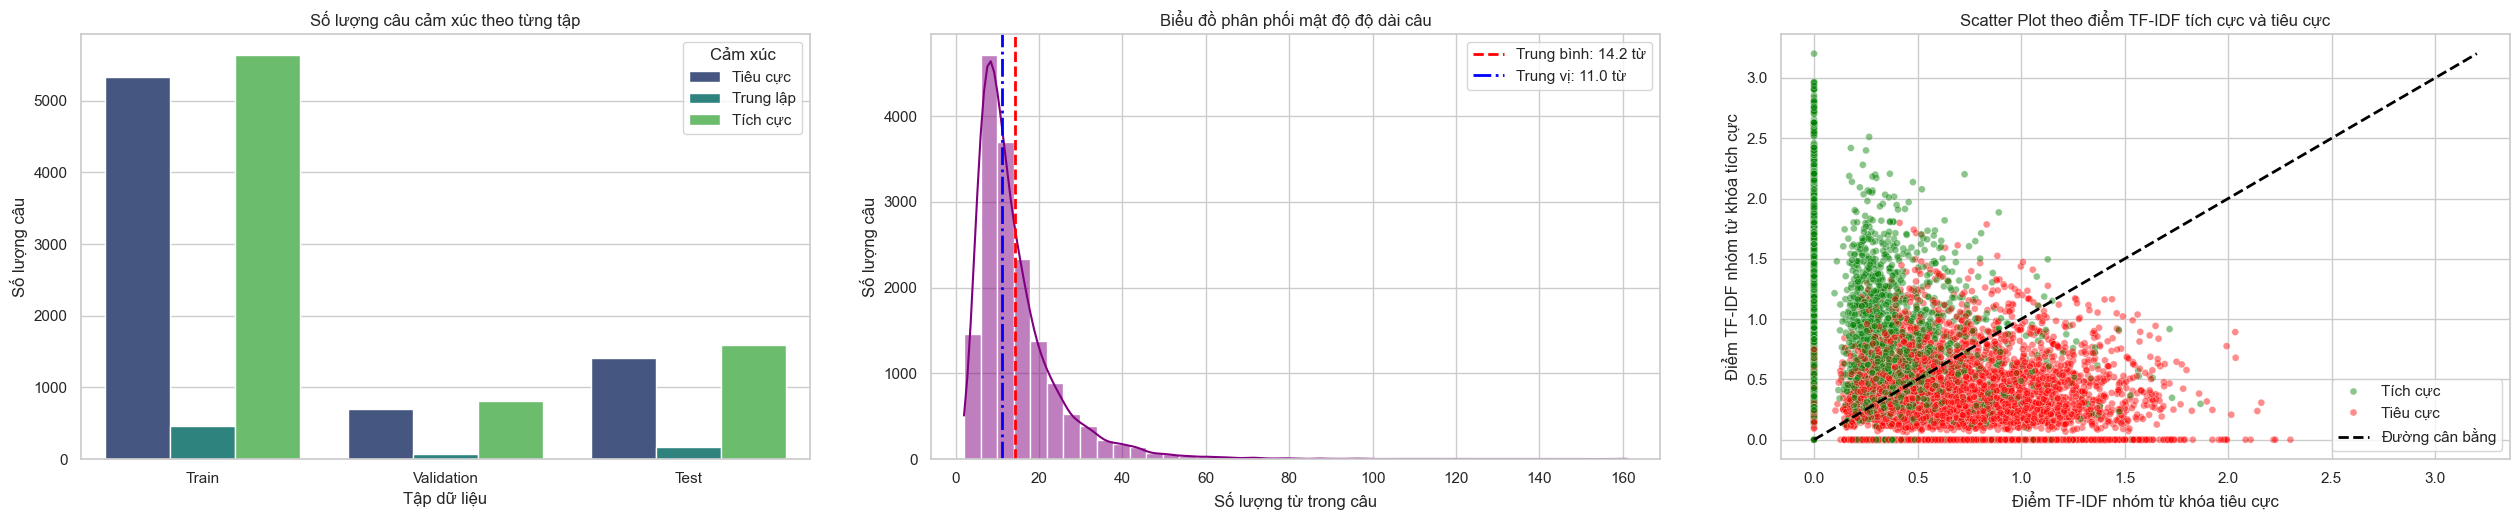

In [8]:
# Cấu hình phong cách biểu đồ
sns.set_theme(style="whitegrid")

# KHỞI TẠO 3 BIỂU ĐỒ EDA TRÊN 1 HÀNG
fig, axes = plt.subplots(1, 3, figsize=(26, 6))

# BIỂU ĐỒ SỐ LƯỢNG CÂU THEO TẬP DỮ LIỆU
sns.countplot(
    data=df_all,
    x='set',
    hue='sentiment_label',
    palette='viridis',
    ax=axes[0],
    order=['Train', 'Validation', 'Test'],
    hue_order=sentiment_order
)

axes[0].set(
    title='Số lượng câu cảm xúc theo từng tập',
    xlabel='Tập dữ liệu',
    ylabel='Số lượng câu'
)
axes[0].legend(title='Cảm xúc')


# BIỂU ĐỒ PHÂN PHỐI ĐỘ DÀI VĂN BẢN
sns.histplot(
    data=df_all,
    x='word_count',
    bins=40,
    kde=True,
    color='purple',
    ax=axes[1]
)

axes[1].set(
    title='Biểu đồ phân phối mật độ độ dài câu',
    xlabel='Số lượng từ trong câu',
    ylabel='Số lượng câu'
)

mean_wc = df_all['word_count'].mean()
median_wc = df_all['word_count'].median()

axes[1].axvline(
    mean_wc,
    color='red',
    linestyle='--',
    linewidth=2,
    label=f'Trung bình: {mean_wc:.1f} từ'
)

axes[1].axvline(
    median_wc,
    color='blue',
    linestyle='-.',
    linewidth=2,
    label=f'Trung vị: {median_wc:.1f} từ'
)

axes[1].legend()

# SCATTER PLOT TÍCH CỰC VS TIÊU CỰC
sentiment_mapping = {
    0: 'Tiêu cực',
    1: 'Trung lập',
    2: 'Tích cực'
}

df_train_viz = df_train.copy()
df_train_viz['sentiment_label'] = df_train_viz['sentiment'].map(sentiment_mapping)

# Tách từ để trực quan hóa nhất quán hơn với mô hình
train_viz_texts = df_train_viz['sentence'].apply(
    lambda text: word_tokenize(str(text), format='text')
)

tfidf_scatter = TfidfVectorizer(
    ngram_range=(1, 1),
    norm='l2',
    min_df=5,
    max_df=0.9
)

X_train_tfidf_scatter = tfidf_scatter.fit_transform(train_viz_texts)

# Chỉ lấy 2 nhãn để scatter dễ quan sát
pos_neg_mask = df_train_viz['sentiment_label'].isin(['Tiêu cực', 'Tích cực'])

X_pos_neg = X_train_tfidf_scatter[pos_neg_mask.values]
df_pos_neg = df_train_viz[pos_neg_mask].reset_index(drop=True)

negative_mask = df_train_viz['sentiment_label'].values == 'Tiêu cực'
positive_mask = df_train_viz['sentiment_label'].values == 'Tích cực'

negative_mean_tfidf = np.asarray(X_train_tfidf_scatter[negative_mask].mean(axis=0)).ravel()
positive_mean_tfidf = np.asarray(X_train_tfidf_scatter[positive_mask].mean(axis=0)).ravel()

top_k = 30

negative_score_diff = negative_mean_tfidf - positive_mean_tfidf
positive_score_diff = positive_mean_tfidf - negative_mean_tfidf

top_negative_indices = negative_score_diff.argsort()[-top_k:]
top_positive_indices = positive_score_diff.argsort()[-top_k:]

negative_axis_score = np.asarray(X_pos_neg[:, top_negative_indices].sum(axis=1)).ravel()
positive_axis_score = np.asarray(X_pos_neg[:, top_positive_indices].sum(axis=1)).ravel()

df_scatter = pd.DataFrame({
    'negative_tfidf_score': negative_axis_score,
    'positive_tfidf_score': positive_axis_score,
    'Sentiment': df_pos_neg['sentiment_label']
})

sns.scatterplot(
    data=df_scatter,
    x='negative_tfidf_score',
    y='positive_tfidf_score',
    hue='Sentiment',
    palette={'Tiêu cực': 'red', 'Tích cực': 'green'},
    alpha=0.45,
    s=25,
    ax=axes[2]
)

max_axis = max(
    df_scatter['negative_tfidf_score'].max(),
    df_scatter['positive_tfidf_score'].max()
)

if max_axis == 0:
    max_axis = 1

axes[2].plot(
    [0, max_axis],
    [0, max_axis],
    '--',
    color='black',
    linewidth=2,
    label='Đường cân bằng'
)

axes[2].set(
    title='Scatter Plot theo điểm TF-IDF tích cực và tiêu cực',
    xlabel='Điểm TF-IDF nhóm từ khóa tiêu cực',
    ylabel='Điểm TF-IDF nhóm từ khóa tích cực'
)

axes[2].legend()

plt.tight_layout(pad=3.0)
plt.show()

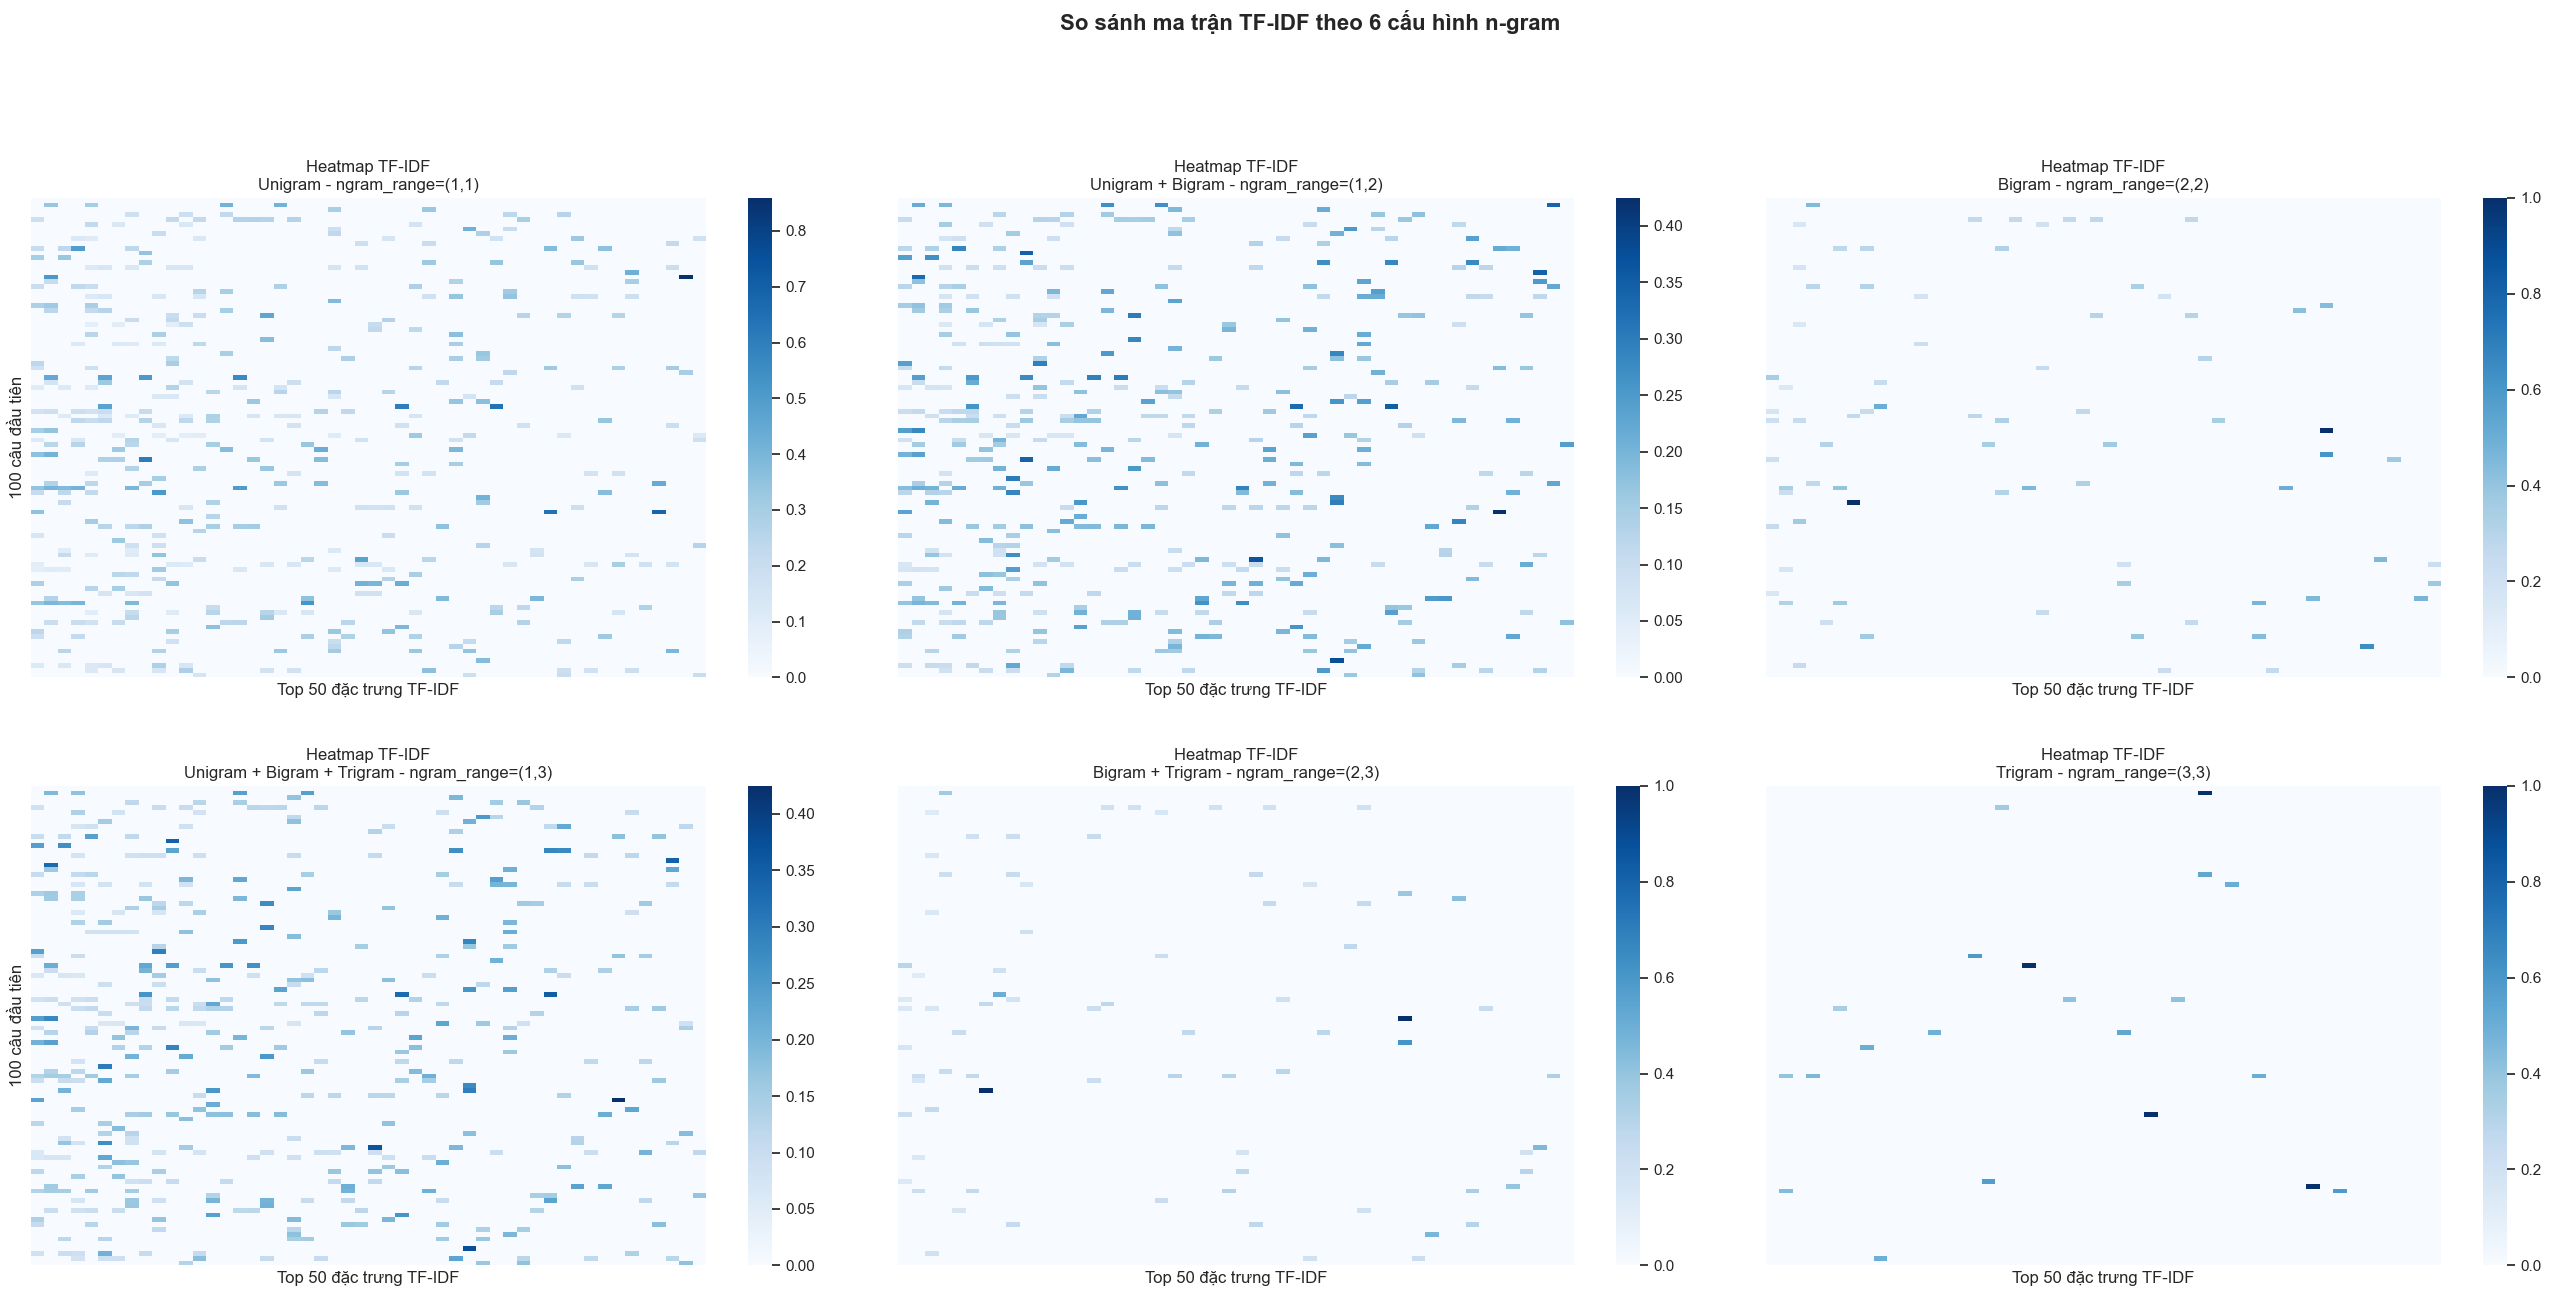

,ngram_range,Số lượng đặc trưng,Mật độ ma trận (%),Top 10 đặc trưng TF-IDF trung bình cao nhất
0,"(1, 1)",1175,0.7273,"thầy, nhiệt_tình, dạy, rất, sinh_viên, hiểu, giảng_viên, và, dễ, không"
1,"(1, 2)",4470,0.2940,"thầy, nhiệt_tình, dạy, sinh_viên, rất, hiểu, giảng_viên, và, không, dễ"
2,"(2, 2)",3295,0.1394,"dễ hiểu, thầy dạy, cho sinh_viên, với sinh_viên, rất nhiệt_tình, dạy rất, cô dạy, thầy rất, khó hiểu, dạy dễ"
3,"(1, 3)",5676,0.2508,"thầy, nhiệt_tình, dạy, sinh_viên, rất, không, giảng_viên, và, hiểu, nhiều"
4,"(2, 3)",4501,0.1264,"dễ hiểu, thầy dạy, cho sinh_viên, với sinh_viên, rất nhiệt_tình, dạy rất, cô dạy, khó hiểu, thầy rất, không có"
5,"(3, 3)",1206,0.0907,"dạy dễ hiểu, thầy dạy rất, thầy dạy hay, dạy rất hay, thầy rất nhiệt_tình, rất dễ hiểu, dạy rất nhiệt_tình, giảng dễ hiểu, bài_tập về nhà, và dễ hiểu"


In [9]:
# =========================================================
# HEATMAP MA TRẬN TF-IDF THEO 6 CẤU HÌNH N-GRAM
# =========================================================
ngram_viz_list = [
    ((1, 1), 'Unigram - ngram_range=(1,1)'),
    ((1, 2), 'Unigram + Bigram - ngram_range=(1,2)'),
    ((2, 2), 'Bigram - ngram_range=(2,2)'),
    ((1, 3), 'Unigram + Bigram + Trigram - ngram_range=(1,3)'),
    ((2, 3), 'Bigram + Trigram - ngram_range=(2,3)'),
    ((3, 3), 'Trigram - ngram_range=(3,3)')
]

# Tách từ để trực quan hóa nhất quán với mô hình
train_viz_texts = df_train['sentence'].apply(
    lambda text: word_tokenize(str(text), format='text')
)

fig, axes = plt.subplots(2, 3, figsize=(27, 13))
axes = axes.flatten()

ngram_feature_summary_rows = []

for idx, (ngram_range, title) in enumerate(ngram_viz_list):
    tfidf_viz = TfidfVectorizer(
        ngram_range=ngram_range,
        norm='l2',
        min_df=5,
        max_df=0.9
    )

    X_train_tfidf = tfidf_viz.fit_transform(train_viz_texts)
    feature_names = np.array(tfidf_viz.get_feature_names_out())

    # Chọn 50 đặc trưng có TF-IDF trung bình cao nhất để heatmap có ý nghĩa hơn
    mean_tfidf_scores = np.asarray(X_train_tfidf.mean(axis=0)).ravel()
    top_50_indices = mean_tfidf_scores.argsort()[-50:][::-1]
    top_10_indices = mean_tfidf_scores.argsort()[-10:][::-1]

    heatmap_matrix = X_train_tfidf[:100, top_50_indices].toarray()

    sns.heatmap(
        heatmap_matrix,
        cmap="Blues",
        cbar=True,
        ax=axes[idx],
        xticklabels=False,
        yticklabels=False
    )

    axes[idx].set(
        title=f"Heatmap TF-IDF\n{title}",
        xlabel="Top 50 đặc trưng TF-IDF",
        ylabel="100 câu đầu tiên" if idx % 3 == 0 else ""
    )

    density = X_train_tfidf.nnz / (X_train_tfidf.shape[0] * X_train_tfidf.shape[1])

    ngram_feature_summary_rows.append({
        'ngram_range': str(ngram_range),
        'Số lượng đặc trưng': X_train_tfidf.shape[1],
        'Mật độ ma trận (%)': density * 100,
        'Top 10 đặc trưng TF-IDF trung bình cao nhất': ', '.join(feature_names[top_10_indices])
    })

plt.suptitle(
    "So sánh ma trận TF-IDF theo 6 cấu hình n-gram",
    fontsize=16,
    fontweight='bold',
    y=1.02
)

plt.tight_layout(pad=3.0)
plt.show()

ngram_feature_summary_df = pd.DataFrame(ngram_feature_summary_rows)

display(
    ngram_feature_summary_df.style.format({
        'Mật độ ma trận (%)': '{:.4f}'
    })
)

### Phân tích 6 heatmap TF-IDF theo cấu hình n-gram

Các heatmap trên biểu diễn cường độ TF-IDF của 100 câu đầu tiên trên 50 đặc trưng có điểm TF-IDF trung bình cao nhất trong từng cấu hình `ngram_range`.

Về mặt toán học, với một đặc trưng \(t\) trong câu \(d\), TF-IDF có thể viết dưới dạng:

$$
\operatorname{tfidf}(t,d)
=
\operatorname{tf}(t,d)
\times
\operatorname{idf}(t).
$$

Trong đó, \(\operatorname{tf}(t,d)\) đo mức độ xuất hiện của đặc trưng trong câu, còn \(\operatorname{idf}(t)\) làm giảm trọng số của các đặc trưng xuất hiện quá phổ biến trong toàn bộ corpus.

Với một câu có \(L\) token, số lượng n-gram độ dài \(n\) có thể sinh ra là:

$$
\max(L-n+1,0).
$$

Vì vậy, khi tăng từ unigram lên bigram/trigram, số đặc trưng tiềm năng tăng lên, nhưng mỗi đặc trưng lại xuất hiện thưa hơn. Điều này giải thích vì sao các heatmap của trigram thường có xu hướng thưa hơn hoặc xuất hiện các vùng sáng rời rạc hơn.

#### 1. `ngram_range=(1,1)` — Unigram

Cấu hình này chỉ dùng từng từ đơn làm đặc trưng. Ưu điểm là các đặc trưng xuất hiện thường xuyên hơn, ít thưa hơn và dễ học hơn với dữ liệu ngắn. Tuy nhiên, unigram có thể mất ngữ cảnh. Ví dụ, từ “không” và từ “tốt” nếu xét riêng có thể không đủ để biểu diễn cụm “không tốt”.

#### 2. `ngram_range=(1,2)` — Unigram + Bigram

Cấu hình này kết hợp từ đơn và cụm 2 từ. Đây thường là cấu hình cân bằng hơn vì vừa giữ được độ phủ của unigram, vừa bổ sung ngữ cảnh ngắn từ bigram như “nhiệt_tình”, “khó_hiểu”, “không tốt”, “rất hay”.

#### 3. `ngram_range=(2,2)` — Bigram

Cấu hình này chỉ dùng cụm 2 từ. Bigram có thể biểu diễn sắc thái tốt hơn unigram trong nhiều trường hợp, nhưng sẽ mất các tín hiệu từ đơn quan trọng. Nếu một câu ngắn chỉ có vài token, số bigram sinh ra ít hơn số unigram, làm ma trận đặc trưng thưa hơn.

#### 4. `ngram_range=(1,3)` — Unigram + Bigram + Trigram

Cấu hình này có không gian đặc trưng lớn hơn vì kết hợp cả từ đơn, cụm 2 từ và cụm 3 từ. Ưu điểm là bắt được nhiều mẫu ngữ cảnh hơn. Tuy nhiên, trigram thường lặp lại ít hơn giữa Train và Test, nên có thể làm tăng độ thưa của ma trận.

#### 5. `ngram_range=(2,3)` — Bigram + Trigram

Cấu hình này loại bỏ unigram và chỉ giữ các cụm từ bậc cao. Nó có thể hữu ích nếu cảm xúc chủ yếu nằm trong cụm từ, nhưng cũng rủi ro vì mất các từ đơn có ý nghĩa mạnh. Nếu heatmap của cấu hình này thưa hơn rõ rệt, điều đó cho thấy các cụm dài ít lặp lại trong corpus.

#### 6. `ngram_range=(3,3)` — Trigram

Cấu hình này chỉ dùng cụm 3 từ. Đây là cấu hình có tính ngữ cảnh cao nhất trong nhóm thử nghiệm, nhưng cũng dễ bị thưa nhất. Với UIT-VSFC, phần lớn câu phản hồi là câu ngắn, nên trigram có thể không ổn định bằng unigram hoặc unigram + bigram.

Tóm lại, heatmap không dùng để kết luận trực tiếp mô hình nào tốt nhất, mà dùng để quan sát mức độ thưa và mức độ tập trung của đặc trưng. Kết luận cuối cùng vẫn cần dựa trên `CV Macro F1`, `Test Macro F1`, classification report và confusion matrix.

| STT | Câu phản hồi gốc | Kết quả tách từ (`underthesea`) | Nhãn đúng | Sắc thái từ khóa chính |
|-----|------------------|----------------------------------|-----------|-------------------------|
| 1 | Thầy dạy rất hay và nhiệt tình | Thầy_dạy rất hay và nhiệt_tình | 2 (Pos) | "hay", "nhiệt_tình" mang nghĩa tích cực mạnh |
| 2 | Slide bài giảng quá sơ sài gv nói nhanh | Slide bài_giảng quá sơ_sài gv nói nhanh | 0 (Neg) | "quá sơ_sài", "nói nhanh" mang tính than phiền |
| 3 | Môn học này bình thường, không có gì nổi bật | Môn_học này bình_thường , không có gì nổi_bật | 1 (Neu) | "bình_thường", mang sắc thái trung tính |
| 4 | Học phòng máy lạnh mà nóng như lò thiêu | Học phòng máy_lạnh mà nóng như lò thiêu | 0 (Neg) | Ẩn dụ/So sánh "nóng như lò thiêu" mang sắc thái tiêu cực |
| 5 | Gv dạy cũng được | Gv dạy cũng được | 1 (Neu) | "cũng được" mang sắc thái ba phải, không rõ khen chê |

*Nhận xét từ EDA:* Tập dữ liệu bị mất cân bằng trầm trọng khi nhãn Trung lập chiếm tỷ lệ quá ít. Độ dài câu của nhãn Tiêu cực (0) có xu hướng dài hơn vì sinh viên có nhu cầu giải thích chi tiết lý do không hài lòng.

**Dựa trên số liệu thống kê, ta nhận thấy được dữ liệu có các đặc điểm sau:**
- Tỉ lệ giữa các nhãn ở cả 3 tập Train, Validation và Test gần như tương đương nhau, đảm bảo không có hiện tượng sai lệch phân phối khi đánh giá mô hình.
- Sự mất cân bằng nhãn: Ở bài toán phân loại cảm xúc, nhãn Trung lập tỏ ra hoàn toàn lép vế (~4.3%) so với 2 cực Tích cực và Tiêu cực. Ở bài toán Chủ đề, nhãn Giảng viên chiếm thế độc tôn (>71%) so với các nhóm còn lại.
- Đặc tính văn bản ngắn và không gian vector thưa thớt: Với độ dài trung bình chỉ 14.2 từ/câu và phân phối lệch phải, dữ liệu khi được số hóa bằng TF-IDF sẽ tạo ra một ma trận cực kỳ thưa (tỉ lệ các ô mang giá trị 0 lên tới hơn 99%).
- Sự chồng chéo và phân tán từ vựng: Trong khi các nhãn đa số sở hữu bộ từ vựng đặc trưng rất rõ nét, thì các nhãn thiểu số lại gặp bất lợi. Ví dụ, nhãn trung lập thường chứa các câu mang tính đánh đổi (vừa có từ khen, vừa có từ chê), hay nhãn khác không có từ khóa định vị rõ ràng.
- Tính phân cực và quy luật phân bố: Dựa trên biểu đồ nén không gian vector bằng, mặc dù dữ liệu bị ép xuống không gian 2 chiều và có hiện tượng chồng chéo, ta vẫn quan sát thấy một quy luật dịch chuyển rõ rệt. Cụ thể, các điểm màu Xanh (Tích cực) có xu hướng tràn về phía dưới/bên phải, trong khi các điểm màu Đỏ (Tiêu cực) tràn về phía trên/bên trái. Sự dịch chuyển khối lượng này chứng minh rằng dù bị nén, dữ liệu vẫn giữ được tính phân cực cảm xúc.
### Nhận xét từ phân tích dữ liệu

Từ bảng thống kê và biểu đồ trực quan, có thể rút ra các đặc điểm sau:

1. **Phân phối nhãn giữa Train, Validation và Test tương đối ổn định.**  
   Tỷ lệ Tiêu cực, Trung lập và Tích cực ở ba tập không lệch nhau quá lớn. Điều này giúp việc đánh giá trên Test đáng tin cậy hơn vì Test không bị thay đổi phân phối quá mạnh so với Train.

2. **Nhãn Trung lập bị thiểu số rõ rệt.**  
   Toàn bộ dữ liệu hiện tại có 698 câu Trung lập trên 16.175 câu:

\[
\frac{698}{16175}\times100\approx4.3\%.
\]

Tỷ lệ này gần với nhận xét trong bài báo gốc rằng nhãn Neutral chỉ chiếm khoảng 4.32% corpus. Khi số mẫu của một lớp quá nhỏ, mô hình khó học được ranh giới ổn định cho lớp đó.

3. **Câu phản hồi thường ngắn.**  
   Độ dài trung bình trong notebook là khoảng 14.2 từ/câu. Với một câu có \(L\) token, số n-gram độ dài \(n\) là:

\[
\max(L-n+1,0).
\]

Khi \(L\) nhỏ, các đặc trưng n-gram bậc cao dễ trở nên thưa và khó lặp lại giữa Train và Test.

4. **TF-IDF tạo ra không gian đặc trưng thưa.**  
   Trong biểu diễn TF-IDF, mỗi cột là một từ/cụm từ. Một câu ngắn chỉ chứa một số rất nhỏ đặc trưng trong toàn bộ từ vựng, nên phần lớn ô trong vector có giá trị 0. Đây là lý do các mô hình tuyến tính như Linear SVM thường được dùng cho phân loại văn bản.

5. **Scatter plot chỉ là biểu diễn trực quan hỗ trợ.**  
   Biểu đồ scatter trong notebook không chứng minh rằng toàn bộ dữ liệu có thể tách tuyến tính hoàn hảo. Nó chỉ minh họa xu hướng phân bố theo hai nhóm điểm TF-IDF đại diện cho các từ khóa thiên về Tích cực và Tiêu cực.

**Từ những phân tích đặc trưng trên, đề xuất định hướng mô hình và chiến lược tối ưu như sau:**
1. Lựa chọn thuật toán:
Với đặc thù của bài toán phân loại văn bản là tạo ra ma trận đặc trưng rất thưa (high-dimensional sparse matrix), Linear SVM là một thuật toán đáng tin cậy. Cơ sở của lựa chọn này dựa trên nghiên cứu của Joachims (1998) [1], trong đó chỉ ra rằng dữ liệu văn bản thường có tính phân tách tuyến tính tự nhiên (linear separability). Về mặt cơ chế, quá trình tối ưu hóa siêu mặt phẳng của SVM sử dụng phép tích vô hướng. Điều này giúp thuật toán tự động bỏ qua các phép tính trên những đặc trưng mang giá trị 0 (vốn chiếm hơn 99% không gian ma trận). Nhờ vậy, Linear SVM xử lý dữ liệu nhiều chiều rất hiệu quả, mang lại tốc độ huấn luyện nhanh, tiết kiệm tài nguyên bộ nhớ nhưng vẫn đảm bảo khả năng tổng quát hóa tốt trên dữ liệu thực tế.
2. Xử lý mất cân bằng và tối ưu đặc trưng:
Để khắc phục tình trạng phân phối dữ liệu bị lệch do sự chênh lệch lớn về số lượng mẫu giữa các nhãn, tham số class_weight='balanced' đã được cấu hình cho mô hình SVM. Về mặt bản chất, cơ chế này sẽ tự động tính toán và áp dụng tham số phạt (penalty parameter $C$) cao hơn đối với các trường hợp dự đoán sai ở nhóm thiểu số. Nhờ vậy, ranh giới phân loại (siêu mặt phẳng) sẽ được tinh chỉnh để nhận diện tốt hơn các nhãn có ít dữ liệu, tránh tình trạng mô hình chỉ học vẹt theo nhãn đa số. Đồng thời, việc kết hợp tinh chỉnh ngưỡng max_df trong TF-IDF hoạt động như một bộ lọc nhiễu tự nhiên, giúp loại bỏ các từ phổ biến không mang giá trị phân loại và tập trung vào các đặc trưng quan trọng.
3. Lựa chọn chỉ số đánh giá:
Do đặc thù dữ liệu mất cân bằng, việc đánh giá mô hình bằng Độ chính xác tổng thể (Accuracy) sẽ không phản ánh đúng hiệu năng thực tế. Thay vào đó, ta có thể sử dụng chỉ số Macro F1-Score. Chỉ số này tiến hành tính trung bình điểm F1 của từng nhãn một cách bình đẳng, không phụ thuộc vào số lượng dữ liệu của nhãn đó.

[1] T. Joachims, "Text categorization with Support Vector Machines: Learning with many relevant features", 1998.

### Cơ sở lựa chọn TF-IDF + Linear SVM

#### 1. TF-IDF

Với một đặc trưng \(t\) trong văn bản \(d\), trọng số TF-IDF có dạng tổng quát:

\[
\operatorname{tfidf}(t,d)=\operatorname{tf}(t,d)\times\operatorname{idf}(t).
\]

Trong đó, \(\operatorname{tf}(t,d)\) đo tần suất của đặc trưng trong văn bản, còn \(\operatorname{idf}(t)\) giảm trọng số của các đặc trưng xuất hiện quá phổ biến trong toàn bộ corpus. Do đó, TF-IDF giúp nhấn mạnh các từ/cụm từ có khả năng phân biệt cảm xúc.

Tham số `max_df` trong `TfidfVectorizer` dùng để loại bỏ những đặc trưng xuất hiện trong tỷ lệ văn bản quá cao. Nếu một từ xuất hiện gần như ở mọi câu, từ đó thường ít hữu ích cho phân loại.

#### 2. Linear SVM

Linear SVM học một hàm quyết định tuyến tính:

\[
f(\mathbf{x})=\mathbf{w}^{T}\mathbf{x}+b.
\]

Trong trường hợp nhị phân, mục tiêu tối ưu có thể viết dưới dạng:

\[
\min_{\mathbf{w},b}
\frac{1}{2}\|\mathbf{w}\|^2
+
C\sum_{i=1}^{N}
\max(0,1-y_i(\mathbf{w}^{T}\mathbf{x}_i+b)).
\]

Trong đó:
- \(\frac{1}{2}\|\mathbf{w}\|^2\) là thành phần regularization;
- \(\max(0,1-y_if(\mathbf{x}_i))\) là hinge loss;
- \(C\) điều khiển mức phạt khi mô hình phân loại sai hoặc vi phạm margin.

Dữ liệu văn bản TF-IDF có số chiều lớn và thưa. Joachims (1998) cho rằng SVM phù hợp với phân loại văn bản vì có khả năng học trong không gian nhiều đặc trưng liên quan.

#### 3. Xử lý mất cân bằng nhãn

Notebook dùng:

```python
class_weight='balanced'
```

Với cơ chế cân bằng lớp, trọng số của lớp \(c\) thường tỷ lệ nghịch với số mẫu của lớp đó:

\[
w_c=\frac{N}{K\cdot N_c},
\]

trong đó \(N\) là tổng số mẫu, \(K\) là số lớp, và \(N_c\) là số mẫu của lớp \(c\). Vì lớp Trung lập có ít mẫu, lỗi trên lớp này được phạt mạnh hơn.

#### 4. Vì sao dùng Macro F1?

Với từng lớp \(c\):

\[
Precision_c=\frac{TP_c}{TP_c+FP_c},
\quad
Recall_c=\frac{TP_c}{TP_c+FN_c},
\quad
F1_c=\frac{2Precision_cRecall_c}{Precision_c+Recall_c}.
\]

Macro F1 được tính bằng:

\[
MacroF1=\frac{1}{K}\sum_{c=1}^{K}F1_c.
\]

Macro F1 phù hợp với dữ liệu mất cân bằng vì mỗi lớp có trọng số ngang nhau, kể cả lớp Trung lập có rất ít mẫu.

**Nguồn tham khảo:** Nguyen et al. (2018); Joachims (1998); scikit-learn documentation for `TfidfVectorizer`, `LinearSVC`, and balanced class weights.

### **3. CÀI ĐẶT MÔ HÌNH**

In [10]:
#Định nghĩa hàm tách từ và nối lại thành chuỗi bằng khoảng trắng
def preprocess_text(text):
    return underthesea.word_tokenize(text, format="text")

In [11]:
# Ví dụ sau khi đã định nghĩa hàm preprocess_text
sample_text = "Thầy dạy rất hay và nhiệt tình, slide bài giảng không bị sơ sài."
print("Câu gốc chưa xử lý :", sample_text)
print("Sau khi qua Tokenizer:", preprocess_text(sample_text))

Câu gốc chưa xử lý : Thầy dạy rất hay và nhiệt tình, slide bài giảng không bị sơ sài.
Sau khi qua Tokenizer: Thầy dạy rất hay và nhiệt_tình , slide bài giảng không bị sơ_sài .


In [12]:
df_train_full = pd.concat([df_train, df_val], ignore_index=True)

print("Đang tiến hành tách từ cho tập Train tổng hợp và tập Test (Vui lòng đợi vài giây)...")
X_train_seg = df_train_full['sentence'].apply(preprocess_text)
y_train = df_train_full['sentiment']

X_test_seg = df_test['sentence'].apply(preprocess_text)
y_test = df_test['sentiment']

Đang tiến hành tách từ cho tập Train tổng hợp và tập Test (Vui lòng đợi vài giây)...


### Ý nghĩa bước tiền xử lý

Hàm `preprocess_text` dùng `underthesea.word_tokenize` để tách từ và nối các từ nhiều âm tiết bằng dấu gạch dưới. Ví dụ:

\[
\text{“nhiệt tình”}\rightarrow \text{“nhiệt\_tình”}.
\]

Đây là bước quan trọng vì TF-IDF hoạt động trên các token. Nếu cụm nhiều âm tiết bị tách sai, mô hình có thể mất các tín hiệu cảm xúc quan trọng. Sau đó, notebook gộp Train và Validation thành `df_train_full` để sử dụng toàn bộ dữ liệu không thuộc Test cho huấn luyện và chọn tham số. Tập Test được giữ riêng để đánh giá cuối cùng.

In [13]:
def build_sentiment_pipeline(ngram_range):
    return Pipeline([
        ('tfidf', TfidfVectorizer(
            ngram_range=ngram_range,
            norm='l2',
            min_df=5
        )),
        ('svm', LinearSVC(
            class_weight='balanced',
            random_state=42,
            max_iter=2000
        ))
    ])

print("Đã định nghĩa pipeline TF-IDF + SVM theo từng ngram_range.")

Đã định nghĩa pipeline TF-IDF + SVM theo từng ngram_range.


In [14]:
# Thiết lập không gian tham số cần thử nghiệm
ngram_ranges = [
    (1, 1),  # unigram
    (1, 2),  # unigram + bigram
    (2, 2),  # bigram
    (1, 3),  # unigram + bigram + trigram
    (2, 3),  # bigram + trigram
    (3, 3),  # trigram
]

param_grid = {
    'tfidf__max_df': [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9],
    'svm__C': [0.2, 0.4, 0.6, 0.8, 1.0, 5.0, 10.0]
}

# Các mốc số lượng câu train dùng để vẽ learning curve. Mốc cuối cùng luôn là toàn bộ tập train đang dùng
total_train_size_for_curve = len(X_train_seg)

learning_curve_train_sizes = [
    500,
    1000,
    2000,
    4000,
    6000,
    8000,
    10000,
    12000,
    total_train_size_for_curve
]

learning_curve_train_sizes = sorted(list(set([
    size for size in learning_curve_train_sizes
    if size <= total_train_size_for_curve
])))

### Thiết lập mô hình và không gian tham số

Pipeline chính gồm hai bước:

1. `TfidfVectorizer(ngram_range=(1,2), norm='l2', min_df=5)`;
2. `LinearSVC(class_weight='balanced')`.

Cấu hình `ngram_range=(1,2)` nghĩa là mô hình dùng cả unigram và bigram. Về mặt đặc trưng, nếu câu đã tách từ là:

\[
[w_1,w_2,\ldots,w_L],
\]

thì tập đặc trưng gồm:

\[
\{w_1,\ldots,w_L\}
\cup
\{(w_1,w_2),(w_2,w_3),\ldots,(w_{L-1},w_L)\}.
\]

GridSearchCV thử 63 cặp tham số:

\[
9\ \text{giá trị } max\_df
\times
7\ \text{giá trị } C
=
63.
\]

Với `cv=5`, tổng số lượt fit là:

\[
63\times5=315.
\]

### **4. TRỰC QUAN VÀ PHÂN TÍCH KẾT QUẢ**

In [15]:
grid_search_by_ngram = {}
model_results = []
learning_curve_rows = []

# Chuẩn bị dữ liệu cho learning curve
train_curve_df = pd.DataFrame({
    'sentence': pd.Series(X_train_seg).reset_index(drop=True),
    'sentiment': pd.Series(y_train).reset_index(drop=True)
})

X_test_curve = pd.Series(X_test_seg).reset_index(drop=True)
y_test_curve = pd.Series(y_test).reset_index(drop=True)

total_start_time = time.time()

for ngram_range in ngram_ranges:
    print("=" * 80)
    print(f"Đang huấn luyện với ngram_range={ngram_range}")
    
    start_time = time.time()
    
    pipeline = build_sentiment_pipeline(ngram_range)
    
    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        cv=5,
        scoring='f1_macro',
        n_jobs=-1,
        verbose=1
    )
    
    grid_search.fit(X_train_seg, y_train)
    
    best_model = grid_search.best_estimator_
    best_params = grid_search.best_params_
    
    y_train_pred = best_model.predict(X_train_seg)
    y_test_pred = best_model.predict(X_test_seg)
    
    train_acc = accuracy_score(y_train, y_train_pred)
    train_macro_f1 = f1_score(y_train, y_train_pred, average='macro')
    
    test_acc = accuracy_score(y_test, y_test_pred)

    test_precision = precision_score(
        y_test,
        y_test_pred,
        average='macro',
        zero_division=0
    )

    test_recall = recall_score(
        y_test,
        y_test_pred,
        average='macro',
        zero_division=0
    )

    test_macro_f1 = f1_score(
        y_test,
        y_test_pred,
        average='macro',
        zero_division=0
    )

    test_weighted_f1 = f1_score(
        y_test,
        y_test_pred,
        average='weighted',
        zero_division=0
    )
    
    fit_time = time.time() - start_time
    
    ngram_key = str(ngram_range)
    
    grid_search_by_ngram[ngram_key] = {
        'grid_search': grid_search,
        'best_model': best_model,
        'y_train_pred': y_train_pred,
        'y_test_pred': y_test_pred
    }
    
    model_results.append({
        'ngram_range': ngram_key,
        'best_max_df': best_params['tfidf__max_df'],
        'best_C': best_params['svm__C'],
        'best_cv_macro_f1': grid_search.best_score_,
        'train_accuracy': train_acc,
        'train_macro_f1': train_macro_f1,
        'test_accuracy': test_acc,
        'test_precision': test_precision,
        'test_recall': test_recall,
        'test_macro_f1': test_macro_f1,
        'test_weighted_f1': test_weighted_f1,
        'fit_time_sec': fit_time
    })
    
    print(f"Hoàn tất GridSearch ngram_range={ngram_range} sau {fit_time:.2f} giây")
    print(f"Best params: {best_params}")
    print(f"Best CV Macro F1: {grid_search.best_score_ * 100:.2f}%")
    print(f"Test Accuracy: {test_acc * 100:.2f}%")
    print(f"Test Macro F1: {test_macro_f1 * 100:.2f}%")
    
    # TẠO LEARNING CURVE NGAY TRONG LUỒNG TRAIN CHÍNH
    print(f"Đang tạo learning curve cho ngram_range={ngram_range}")
    
    for train_size in learning_curve_train_sizes:
        
        # Với mốc cuối dùng toàn bộ train set:
        # Reuse chính best_model đã train ở trên để đảm bảo khớp comparison_df
        if train_size == total_train_size_for_curve:
            curve_accuracy = test_acc
            curve_macro_f1 = test_macro_f1
        
        else:
            subset_sentence, _, subset_sentiment, _ = train_test_split(
                train_curve_df['sentence'],
                train_curve_df['sentiment'],
                train_size=train_size,
                stratify=train_curve_df['sentiment'],
                random_state=42
            )
            
            curve_model = build_sentiment_pipeline(ngram_range)
            
            curve_model.set_params(
                tfidf__max_df=best_params['tfidf__max_df'],
                svm__C=best_params['svm__C']
            )
            
            curve_model.fit(
                subset_sentence.reset_index(drop=True),
                subset_sentiment.reset_index(drop=True)
            )
            
            curve_y_pred = curve_model.predict(X_test_curve)
            
            curve_accuracy = accuracy_score(y_test_curve, curve_y_pred)
            curve_macro_f1 = f1_score(
                y_test_curve,
                curve_y_pred,
                average='macro',
                zero_division=0
            )
        
        learning_curve_rows.append({
            'ngram_range': ngram_key,
            'training_sentences': train_size,
            'test_accuracy': curve_accuracy,
            'test_macro_f1': curve_macro_f1,
            'best_max_df': best_params['tfidf__max_df'],
            'best_C': best_params['svm__C']
        })
        
        print(
            f"Train size={train_size:5d} | "
            f"Accuracy={curve_accuracy:.4f} | "
            f"Macro F1={curve_macro_f1:.4f}"
        )

learning_curve_df = pd.DataFrame(learning_curve_rows)

print("=" * 80)
print(f"Tổng thời gian huấn luyện: {(time.time() - total_start_time) / 60:.2f} phút")

Đang huấn luyện với ngram_range=(1, 1)
Fitting 5 folds for each of 63 candidates, totalling 315 fits
Hoàn tất GridSearch ngram_range=(1, 1) sau 60.10 giây
Best params: {'svm__C': 0.2, 'tfidf__max_df': 0.2}
Best CV Macro F1: 73.89%
Test Accuracy: 87.81%
Test Macro F1: 73.86%
Đang tạo learning curve cho ngram_range=(1, 1)
Train size=  500 | Accuracy=0.8247 | Macro F1=0.6211
Train size= 1000 | Accuracy=0.8430 | Macro F1=0.6807
Train size= 2000 | Accuracy=0.8519 | Macro F1=0.6931
Train size= 4000 | Accuracy=0.8642 | Macro F1=0.7152
Train size= 6000 | Accuracy=0.8721 | Macro F1=0.7256
Train size= 8000 | Accuracy=0.8778 | Macro F1=0.7406
Train size=10000 | Accuracy=0.8825 | Macro F1=0.7453
Train size=12000 | Accuracy=0.8819 | Macro F1=0.7443
Train size=13009 | Accuracy=0.8781 | Macro F1=0.7386
Đang huấn luyện với ngram_range=(1, 2)
Fitting 5 folds for each of 63 candidates, totalling 315 fits
Hoàn tất GridSearch ngram_range=(1, 2) sau 37.56 giây
Best params: {'svm__C': 0.2, 'tfidf__max_df': 

In [16]:
# =========================================================
# BẢNG SO SÁNH KẾT QUẢ TEST THEO N-GRAM
# Cell này chỉ đọc kết quả từ model_results đã tạo ở Cell train chính
# =========================================================

if 'model_results' not in globals():
    raise NameError(
        "Biến model_results chưa tồn tại. "
        "Bạn cần chạy Cell train chính trước khi chạy cell này."
    )

comparison_df = pd.DataFrame(model_results)

required_columns = [
    'ngram_range',
    'test_accuracy',
    'test_precision',
    'test_recall',
    'test_macro_f1',
    'test_weighted_f1',
    'fit_time_sec'
]

missing_columns = [
    col for col in required_columns
    if col not in comparison_df.columns
]

if missing_columns:
    raise KeyError(
        "model_results đang thiếu các cột sau: "
        + ", ".join(missing_columns)
        + ". Bạn cần kiểm tra lại Cell train chính."
    )

comparison_df = comparison_df[required_columns]

comparison_df = comparison_df.sort_values(
    by='test_macro_f1',
    ascending=False
).reset_index(drop=True)

display(
    comparison_df.style.format({
        'test_accuracy': '{:.4f}',
        'test_precision': '{:.4f}',
        'test_recall': '{:.4f}',
        'test_macro_f1': '{:.4f}',
        'test_weighted_f1': '{:.4f}',
        'fit_time_sec': '{:.2f}'
    })
)

best_ngram_key = comparison_df.iloc[0]['ngram_range']
print(f"Ngram tốt nhất theo Test Macro F1: {best_ngram_key}")

,ngram_range,test_accuracy,test_precision,test_recall,test_macro_f1,test_weighted_f1,fit_time_sec
0,"(1, 1)",0.8781,0.7296,0.7517,0.7386,0.8815,60.10
1,"(1, 2)",0.8847,0.7338,0.7281,0.7304,0.8838,37.56
2,"(1, 3)",0.8831,0.7313,0.7217,0.7256,0.8816,51.43
3,"(2, 2)",0.8023,0.6522,0.6915,0.6572,0.8196,24.59
4,"(2, 3)",0.8001,0.6475,0.6827,0.6517,0.8173,38.23
5,"(3, 3)",0.6674,0.5278,0.4902,0.4763,0.6495,23.72


Ngram tốt nhất theo Test Macro F1: (1, 1)


In [17]:
target_names = ['Tiêu cực (0)', 'Trung lập (1)', 'Tích cực (2)']
label_order = [0, 1, 2]

for ngram_key, result in grid_search_by_ngram.items():
    print("=" * 80)
    print(f"CLASSIFICATION REPORT TRÊN TẬP TEST - ngram_range={ngram_key}")
    
    y_test_pred = result['y_test_pred']
    
    print(classification_report(
        y_test,
        y_test_pred,
        labels=label_order,
        target_names=target_names,
        zero_division=0
    ))

CLASSIFICATION REPORT TRÊN TẬP TEST - ngram_range=(1, 1)
               precision    recall  f1-score   support

 Tiêu cực (0)       0.89      0.92      0.90      1409
Trung lập (1)       0.36      0.45      0.40       167
 Tích cực (2)       0.94      0.89      0.91      1590

     accuracy                           0.88      3166
    macro avg       0.73      0.75      0.74      3166
 weighted avg       0.89      0.88      0.88      3166

CLASSIFICATION REPORT TRÊN TẬP TEST - ngram_range=(1, 2)


               precision    recall  f1-score   support

 Tiêu cực (0)       0.88      0.94      0.91      1409
Trung lập (1)       0.38      0.35      0.37       167
 Tích cực (2)       0.94      0.90      0.92      1590

     accuracy                           0.88      3166
    macro avg       0.73      0.73      0.73      3166
 weighted avg       0.88      0.88      0.88      3166

CLASSIFICATION REPORT TRÊN TẬP TEST - ngram_range=(2, 2)
               precision    recall  f1-score   support

 Tiêu cực (0)       0.85      0.85      0.85      1409
Trung lập (1)       0.20      0.43      0.27       167
 Tích cực (2)       0.91      0.80      0.85      1590

     accuracy                           0.80      3166
    macro avg       0.65      0.69      0.66      3166
 weighted avg       0.84      0.80      0.82      3166

CLASSIFICATION REPORT TRÊN TẬP TEST - ngram_range=(1, 3)
               precision    recall  f1-score   support

 Tiêu cực (0)       0.88      0.94      0.91      1409

### Phân tích kết quả Train và Test

Kết quả Train:

\[
Accuracy=86.37\%,\quad MacroF1=71.72\%.
\]

Kết quả Test:

\[
Accuracy=85.03\%,\quad MacroF1=70.18\%.
\]

Chênh lệch giữa Train và Test không quá lớn:

\[
86.37-85.03=1.34\ \text{điểm phần trăm Accuracy},
\]

\[
71.72-70.18=1.54\ \text{điểm phần trăm Macro F1}.
\]

Điều này cho thấy mô hình không có dấu hiệu overfitting quá nghiêm trọng. Tuy nhiên, Macro F1 thấp hơn Accuracy khá nhiều vì lớp Trung lập có F1-score thấp.

Cụ thể trên Test:

\[
F1_{Negative}=0.88,\quad
F1_{Neutral}=0.34,\quad
F1_{Positive}=0.89.
\]

Do Macro F1 tính trung bình đều:

\[
MacroF1
=
\frac{0.88+0.34+0.89}{3}
\approx0.70.
\]

Vì vậy, điểm Macro F1 thấp chủ yếu do nhãn Trung lập.

In [18]:
per_class_rows = []

for ngram_key, result in grid_search_by_ngram.items():
    y_test_pred = result['y_test_pred']
    
    report_dict = classification_report(
        y_test,
        y_test_pred,
        labels=label_order,
        target_names=target_names,
        output_dict=True,
        zero_division=0
    )
    
    for class_name in target_names:
        per_class_rows.append({
            'ngram_range': ngram_key,
            'class': class_name,
            'precision': report_dict[class_name]['precision'],
            'recall': report_dict[class_name]['recall'],
            'f1_score': report_dict[class_name]['f1-score'],
            'support': report_dict[class_name]['support']
        })

per_class_df = pd.DataFrame(per_class_rows)

display(
    per_class_df
    .sort_values(by=['class', 'f1_score'], ascending=[True, False])
    .style.format({
        'precision': '{:.4f}',
        'recall': '{:.4f}',
        'f1_score': '{:.4f}',
        'support': '{:.0f}'
    })
)

,ngram_range,class,precision,recall,f1_score,support
3,"(1, 2)",Tiêu cực (0),0.8828,0.9354,0.9083,1409
9,"(1, 3)",Tiêu cực (0),0.8799,0.9361,0.9072,1409
0,"(1, 1)",Tiêu cực (0),0.8864,0.9191,0.9024,1409
6,"(2, 2)",Tiêu cực (0),0.8509,0.8467,0.8488,1409
12,"(2, 3)",Tiêu cực (0),0.8510,0.8432,0.8471,1409
15,"(3, 3)",Tiêu cực (0),0.5923,0.9155,0.7193,1409
1,"(1, 1)",Trung lập (1),0.3606,0.4491,0.4000,167
4,"(1, 2)",Trung lập (1),0.3806,0.3533,0.3665,167
10,"(1, 3)",Trung lập (1),0.3784,0.3353,0.3556,167
7,"(2, 2)",Trung lập (1),0.1994,0.4251,0.2715,167


,ngram_range,training_sentences,test_accuracy,test_macro_f1,best_max_df,best_C
0,"(1, 1)",500,0.8247,0.6211,0.20,0.20
1,"(1, 1)",1000,0.8430,0.6807,0.20,0.20
2,"(1, 1)",2000,0.8519,0.6931,0.20,0.20
3,"(1, 1)",4000,0.8642,0.7152,0.20,0.20
4,"(1, 1)",6000,0.8721,0.7256,0.20,0.20
5,"(1, 1)",8000,0.8778,0.7406,0.20,0.20
6,"(1, 1)",10000,0.8825,0.7453,0.20,0.20
7,"(1, 1)",12000,0.8819,0.7443,0.20,0.20
8,"(1, 1)",13009,0.8781,0.7386,0.20,0.20
9,"(1, 2)",500,0.8279,0.6198,0.20,0.20


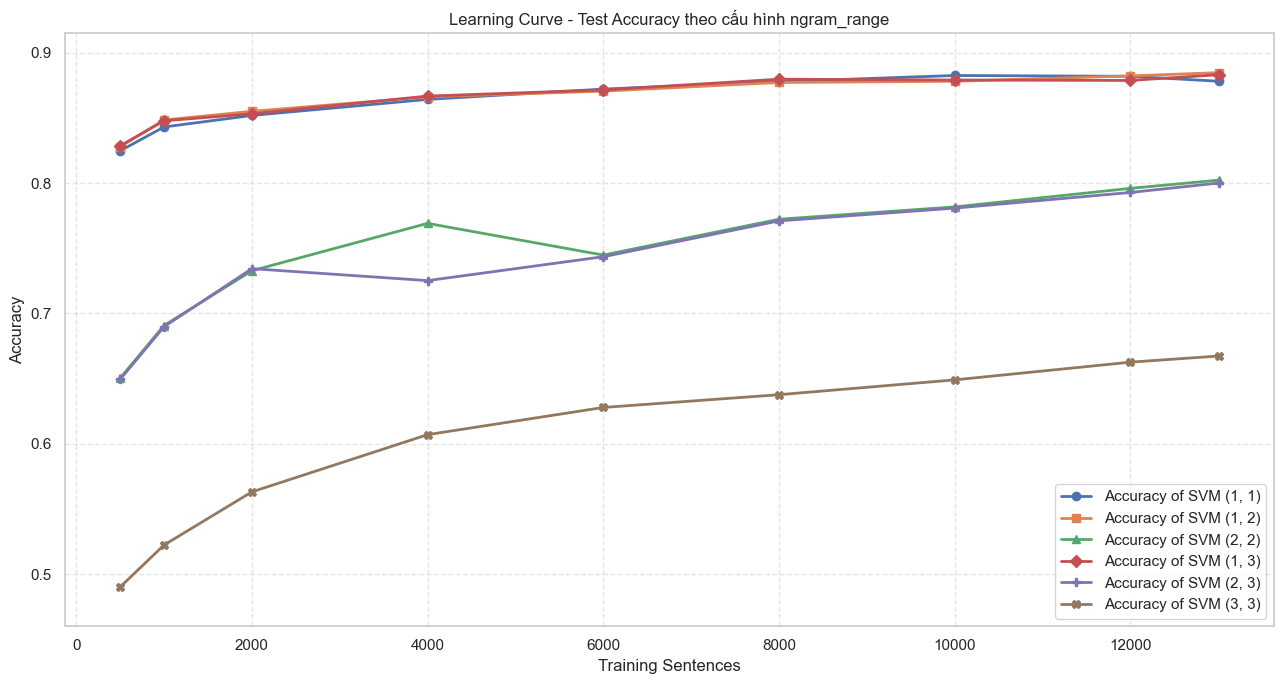

In [19]:
# =========================================================
# LEARNING CURVE - TEST ACCURACY THEO N-GRAM
# =========================================================
display(
    learning_curve_df.style.format({
        'test_accuracy': '{:.4f}',
        'test_macro_f1': '{:.4f}',
        'best_max_df': '{:.2f}',
        'best_C': '{:.2f}'
    })
)

plt.figure(figsize=(13, 7))

markers = {
    '(1, 1)': 'o',
    '(1, 2)': 's',
    '(2, 2)': '^',
    '(1, 3)': 'D',
    '(2, 3)': 'P',
    '(3, 3)': 'X'
}

ordered_ngram_keys = [
    str(ngram_range)
    for ngram_range in ngram_ranges
    if str(ngram_range) in learning_curve_df['ngram_range'].unique()
]

for ngram_key in ordered_ngram_keys:
    ngram_data = learning_curve_df[
        learning_curve_df['ngram_range'] == ngram_key
    ].sort_values('training_sentences')
    
    plt.plot(
        ngram_data['training_sentences'],
        ngram_data['test_accuracy'],
        marker=markers.get(ngram_key, 'o'),
        linewidth=2,
        label=f'Accuracy of SVM {ngram_key}'
    )

plt.xlabel('Training Sentences')
plt.ylabel('Accuracy')
plt.title('Learning Curve - Test Accuracy theo cấu hình ngram_range')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='best')

min_score = learning_curve_df['test_accuracy'].min()
max_score = learning_curve_df['test_accuracy'].max()

plt.ylim(
    max(0, min_score - 0.03),
    min(1, max_score + 0.03)
)

plt.tight_layout()
plt.show()

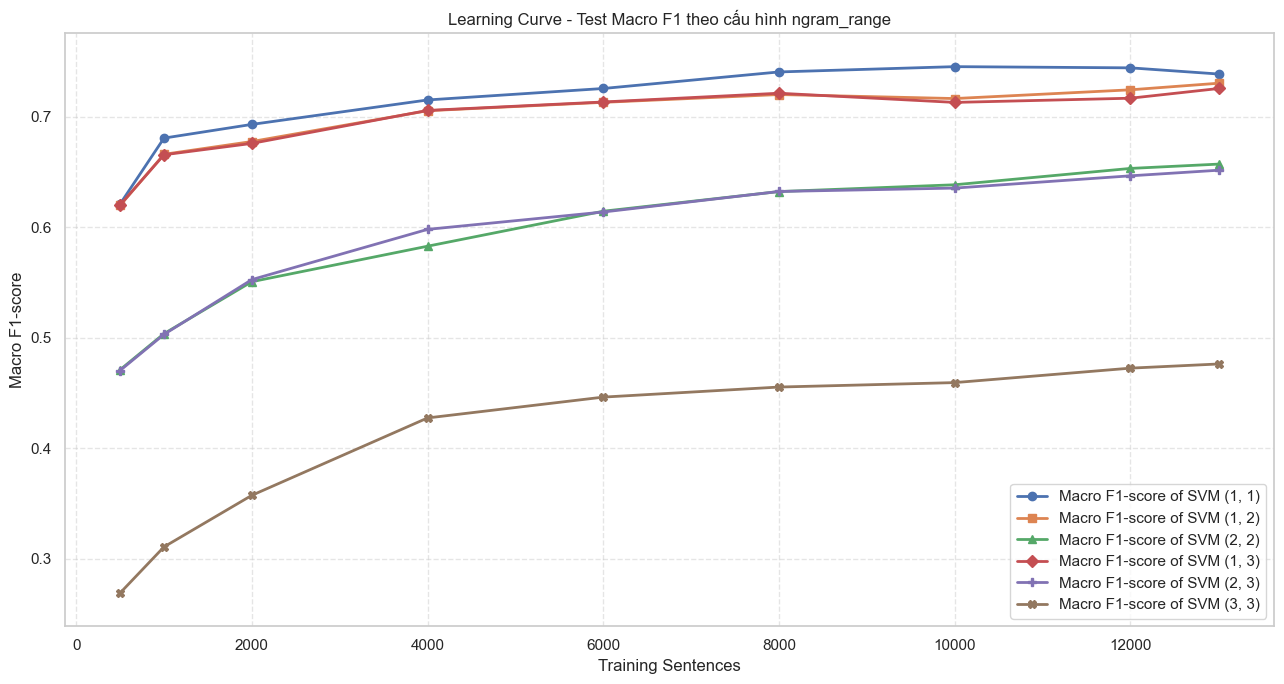

In [20]:
# =========================================================
# LEARNING CURVE - TEST MACRO F1 THEO N-GRAM
# =========================================================
plt.figure(figsize=(13, 7))

markers = {
    '(1, 1)': 'o',
    '(1, 2)': 's',
    '(2, 2)': '^',
    '(1, 3)': 'D',
    '(2, 3)': 'P',
    '(3, 3)': 'X'
}

ordered_ngram_keys = [
    str(ngram_range)
    for ngram_range in ngram_ranges
    if str(ngram_range) in learning_curve_df['ngram_range'].unique()
]

for ngram_key in ordered_ngram_keys:
    ngram_data = learning_curve_df[
        learning_curve_df['ngram_range'] == ngram_key
    ].sort_values('training_sentences')
    
    plt.plot(
        ngram_data['training_sentences'],
        ngram_data['test_macro_f1'],
        marker=markers.get(ngram_key, 'o'),
        linewidth=2,
        label=f'Macro F1-score of SVM {ngram_key}'
    )

plt.xlabel('Training Sentences')
plt.ylabel('Macro F1-score')
plt.title('Learning Curve - Test Macro F1 theo cấu hình ngram_range')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='best')

min_score = learning_curve_df['test_macro_f1'].min()
max_score = learning_curve_df['test_macro_f1'].max()

plt.ylim(
    max(0, min_score - 0.03),
    min(1, max_score + 0.03)
)

plt.tight_layout()
plt.show()

### Phân tích learning curves

Learning curve cho biết khi tăng số lượng câu huấn luyện, mô hình thay đổi hiệu năng như thế nào trên tập Test.

Biểu đồ Accuracy phản ánh tỷ lệ dự đoán đúng tổng thể:

$$
Accuracy
=
\frac{\text{số mẫu dự đoán đúng}}{\text{tổng số mẫu}}.
$$

Tuy nhiên, với dữ liệu mất cân bằng, Accuracy có thể cao ngay cả khi mô hình xử lý kém nhãn thiểu số.

Biểu đồ Macro F1 quan trọng hơn trong bài toán này vì Macro F1 tính trung bình đều F1 của từng lớp:

$$
MacroF1
=
\frac{1}{K}
\sum_{c=1}^{K}F1_c.
$$

Nếu Accuracy tăng nhưng Macro F1 không tăng tương ứng, điều đó cho thấy mô hình chủ yếu cải thiện trên các lớp lớn như Tiêu cực và Tích cực, nhưng chưa cải thiện rõ trên lớp Trung lập.

Khi so sánh các đường n-gram, cần quan sát:
- cấu hình nào học nhanh hơn ở vùng ít dữ liệu;
- cấu hình nào ổn định hơn khi tăng số lượng câu;
- cấu hình nào có khoảng cách lớn giữa Accuracy và Macro F1;
- cấu hình nào đạt điểm cao nhất ở mốc toàn bộ tập train.

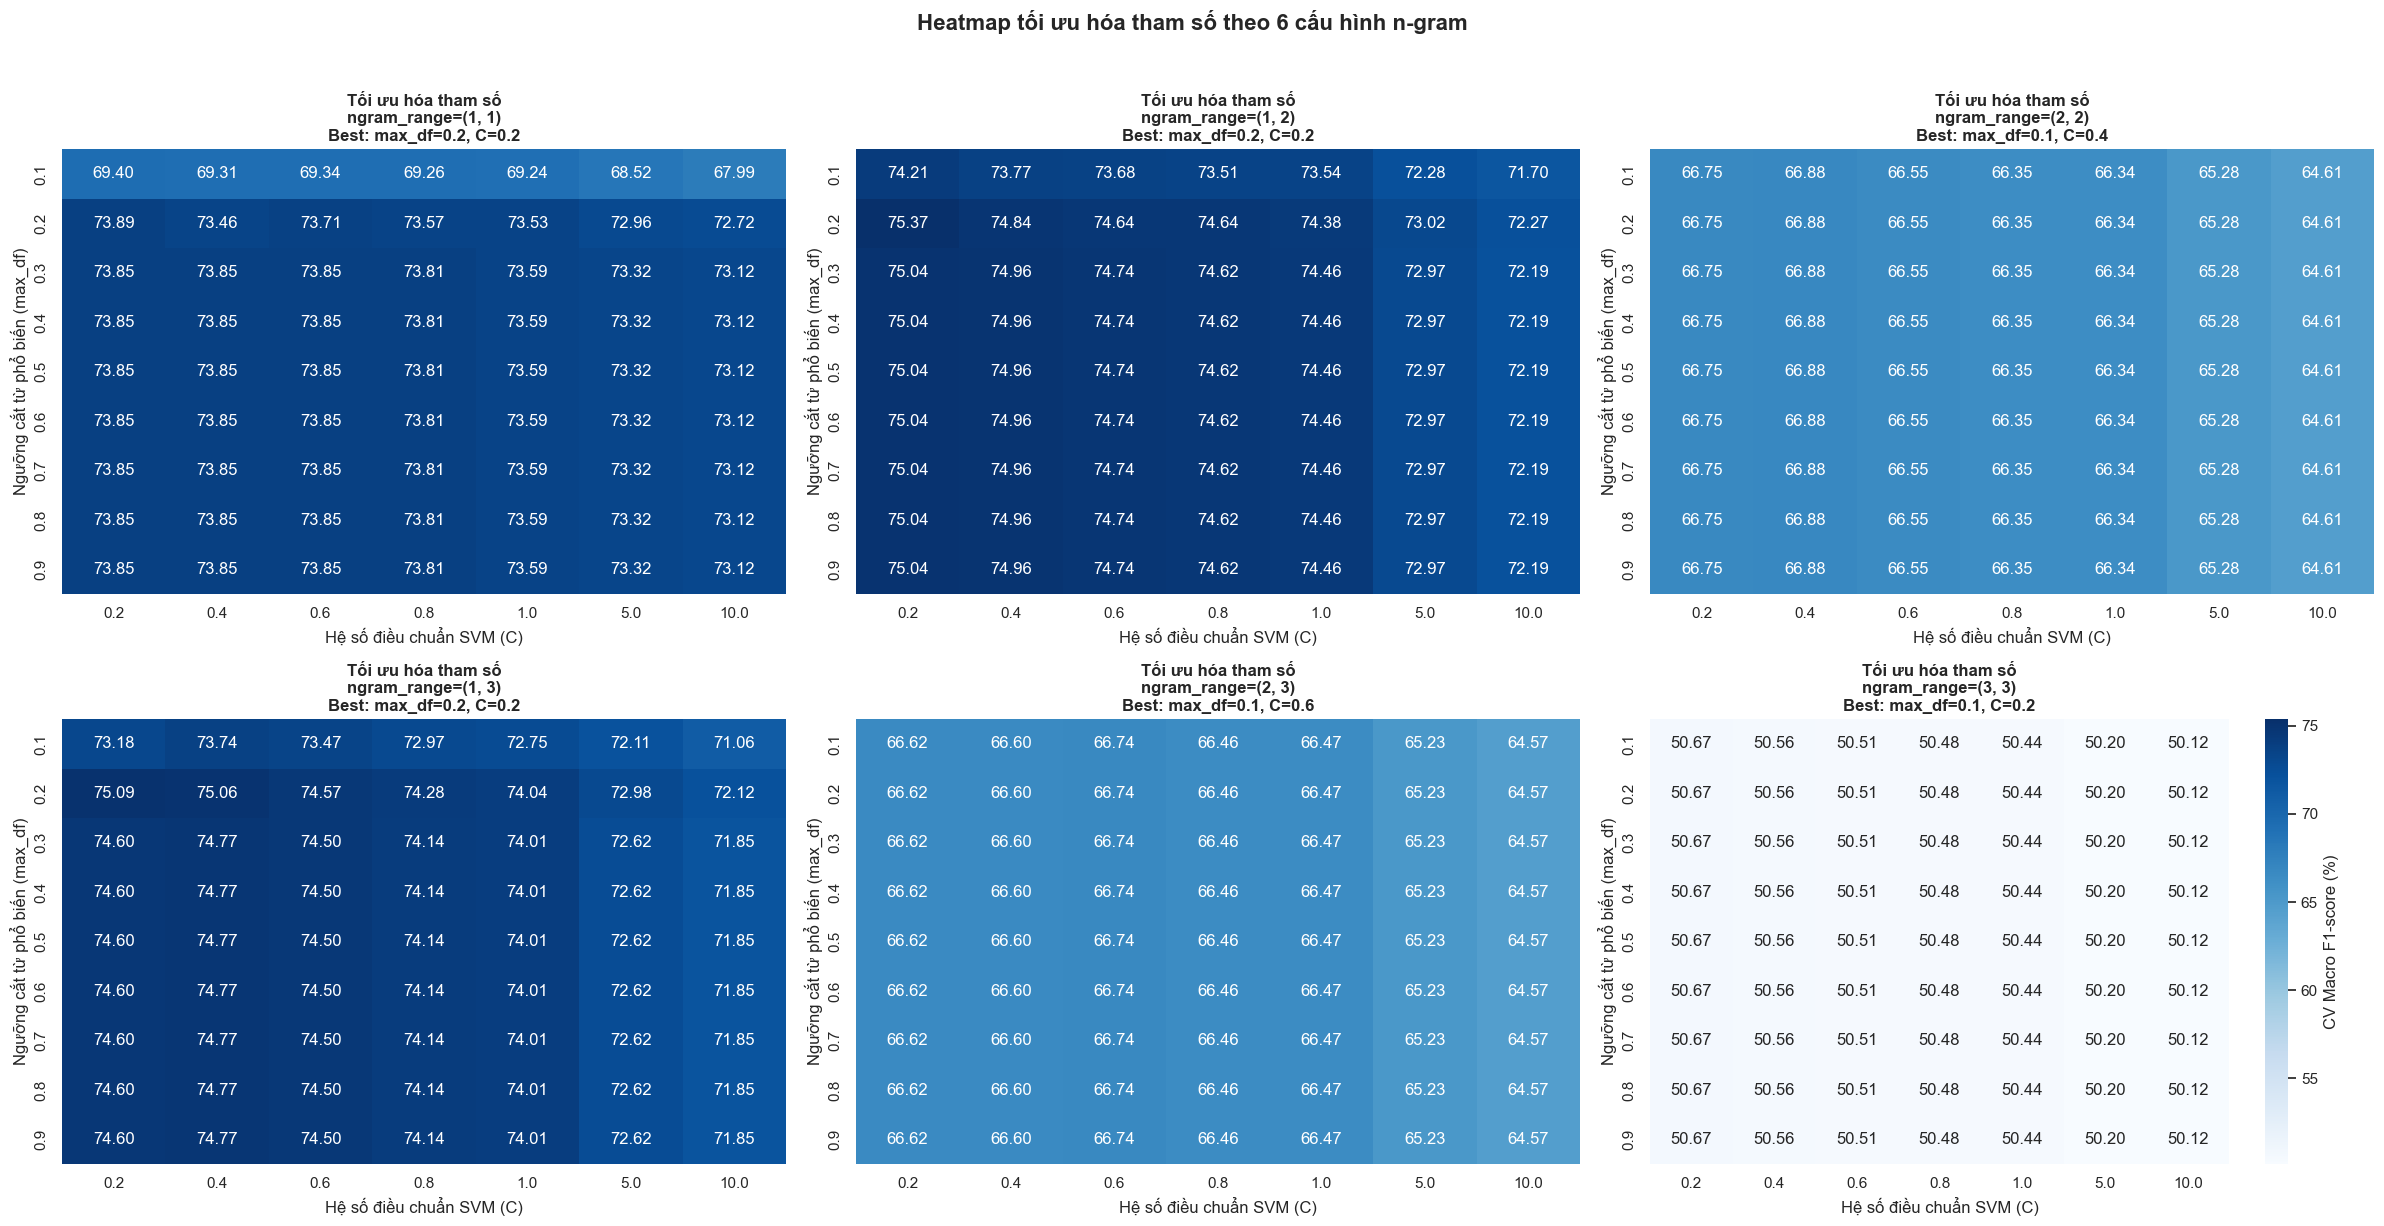

,ngram_range,best_max_df,best_C,best_cv_macro_f1 (%),score_range (%)
0,"(1, 1)",0.20,0.20,73.89,5.90
1,"(1, 2)",0.20,0.20,75.37,3.67
2,"(2, 2)",0.10,0.40,66.88,2.27
3,"(1, 3)",0.20,0.20,75.09,4.04
4,"(2, 3)",0.10,0.60,66.74,2.17
5,"(3, 3)",0.10,0.20,50.67,0.54


In [21]:
# =========================================================
# HEATMAP TỐI ƯU HÓA THAM SỐ CHO 6 N-GRAM
# =========================================================
ngram_keys = [
    str(ngram_range)
    for ngram_range in ngram_ranges
    if str(ngram_range) in grid_search_by_ngram
]

n_cols = 3
n_rows = int(np.ceil(len(ngram_keys) / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(8 * n_cols, 6 * n_rows)
)

axes = np.array(axes).reshape(-1)

# Tính global min/max để màu giữa các heatmap so sánh công bằng
all_cv_scores = []

for ngram_key in ngram_keys:
    grid_search = grid_search_by_ngram[ngram_key]['grid_search']
    cv_df = pd.DataFrame(grid_search.cv_results_)
    all_cv_scores.extend(cv_df['mean_test_score'] * 100)

vmin_cv = min(all_cv_scores)
vmax_cv = max(all_cv_scores)

heatmap_analysis_rows = []

for idx, ngram_key in enumerate(ngram_keys):
    result = grid_search_by_ngram[ngram_key]
    grid_search = result['grid_search']
    best_params = grid_search.best_params_

    cv_df = pd.DataFrame(grid_search.cv_results_)

    cv_df['param_tfidf__max_df'] = cv_df['param_tfidf__max_df'].astype(float)
    cv_df['param_svm__C'] = cv_df['param_svm__C'].astype(float)
    cv_df['mean_test_score_pct'] = cv_df['mean_test_score'] * 100

    heatmap_data = cv_df.pivot_table(
        index='param_tfidf__max_df',
        columns='param_svm__C',
        values='mean_test_score_pct'
    )

    heatmap_data = heatmap_data.sort_index()
    heatmap_data = heatmap_data.reindex(sorted(heatmap_data.columns), axis=1)

    sns.heatmap(
        heatmap_data,
        annot=True,
        fmt='.2f',
        cmap='Blues',
        vmin=vmin_cv,
        vmax=vmax_cv,
        ax=axes[idx],
        cbar=(idx == len(ngram_keys) - 1),
        cbar_kws={'label': 'CV Macro F1-score (%)'}
    )

    axes[idx].set_title(
        f"Tối ưu hóa tham số\nngram_range={ngram_key}\n"
        f"Best: max_df={best_params['tfidf__max_df']}, C={best_params['svm__C']}",
        fontweight='bold'
    )

    axes[idx].set_xlabel('Hệ số điều chuẩn SVM (C)')
    axes[idx].set_ylabel('Ngưỡng cắt từ phổ biến (max_df)')

    best_score_pct = grid_search.best_score_ * 100
    score_range = cv_df['mean_test_score_pct'].max() - cv_df['mean_test_score_pct'].min()

    heatmap_analysis_rows.append({
        'ngram_range': ngram_key,
        'best_max_df': best_params['tfidf__max_df'],
        'best_C': best_params['svm__C'],
        'best_cv_macro_f1 (%)': best_score_pct,
        'score_range (%)': score_range
    })

# Ẩn subplot dư nếu có
for empty_idx in range(len(ngram_keys), len(axes)):
    axes[empty_idx].axis('off')

plt.suptitle(
    "Heatmap tối ưu hóa tham số theo 6 cấu hình n-gram",
    fontsize=16,
    fontweight='bold',
    y=1.02
)

plt.tight_layout()
plt.show()

heatmap_analysis_df = pd.DataFrame(heatmap_analysis_rows)

display(
    heatmap_analysis_df.style.format({
        'best_max_df': '{:.2f}',
        'best_C': '{:.2f}',
        'best_cv_macro_f1 (%)': '{:.2f}',
        'score_range (%)': '{:.2f}'
    })
)

In [22]:
from IPython.display import Markdown, display

for _, row in heatmap_analysis_df.iterrows():
    display(Markdown(f"""
#### Phân tích heatmap tối ưu tham số cho `ngram_range={row['ngram_range']}`

- Bộ tham số tốt nhất theo 5-fold CV là `max_df={row['best_max_df']:.2f}` và `C={row['best_C']:.2f}`.
- CV Macro F1 tốt nhất đạt **{row['best_cv_macro_f1 (%)']:.2f}%**.
- Độ dao động giữa cấu hình tốt nhất và kém nhất trong heatmap là **{row['score_range (%)']:.2f} điểm phần trăm**.

Nếu `score_range` nhỏ, mô hình tương đối ổn định với nhiều cặp tham số khác nhau. Nếu `score_range` lớn, kết quả phụ thuộc mạnh vào lựa chọn `max_df` và `C`, nghĩa là bước tối ưu tham số có ảnh hưởng rõ rệt.
"""))


#### Phân tích heatmap tối ưu tham số cho `ngram_range=(1, 1)`

- Bộ tham số tốt nhất theo 5-fold CV là `max_df=0.20` và `C=0.20`.
- CV Macro F1 tốt nhất đạt **73.89%**.
- Độ dao động giữa cấu hình tốt nhất và kém nhất trong heatmap là **5.90 điểm phần trăm**.

Nếu `score_range` nhỏ, mô hình tương đối ổn định với nhiều cặp tham số khác nhau. Nếu `score_range` lớn, kết quả phụ thuộc mạnh vào lựa chọn `max_df` và `C`, nghĩa là bước tối ưu tham số có ảnh hưởng rõ rệt.



#### Phân tích heatmap tối ưu tham số cho `ngram_range=(1, 2)`

- Bộ tham số tốt nhất theo 5-fold CV là `max_df=0.20` và `C=0.20`.
- CV Macro F1 tốt nhất đạt **75.37%**.
- Độ dao động giữa cấu hình tốt nhất và kém nhất trong heatmap là **3.67 điểm phần trăm**.

Nếu `score_range` nhỏ, mô hình tương đối ổn định với nhiều cặp tham số khác nhau. Nếu `score_range` lớn, kết quả phụ thuộc mạnh vào lựa chọn `max_df` và `C`, nghĩa là bước tối ưu tham số có ảnh hưởng rõ rệt.



#### Phân tích heatmap tối ưu tham số cho `ngram_range=(2, 2)`

- Bộ tham số tốt nhất theo 5-fold CV là `max_df=0.10` và `C=0.40`.
- CV Macro F1 tốt nhất đạt **66.88%**.
- Độ dao động giữa cấu hình tốt nhất và kém nhất trong heatmap là **2.27 điểm phần trăm**.

Nếu `score_range` nhỏ, mô hình tương đối ổn định với nhiều cặp tham số khác nhau. Nếu `score_range` lớn, kết quả phụ thuộc mạnh vào lựa chọn `max_df` và `C`, nghĩa là bước tối ưu tham số có ảnh hưởng rõ rệt.



#### Phân tích heatmap tối ưu tham số cho `ngram_range=(1, 3)`

- Bộ tham số tốt nhất theo 5-fold CV là `max_df=0.20` và `C=0.20`.
- CV Macro F1 tốt nhất đạt **75.09%**.
- Độ dao động giữa cấu hình tốt nhất và kém nhất trong heatmap là **4.04 điểm phần trăm**.

Nếu `score_range` nhỏ, mô hình tương đối ổn định với nhiều cặp tham số khác nhau. Nếu `score_range` lớn, kết quả phụ thuộc mạnh vào lựa chọn `max_df` và `C`, nghĩa là bước tối ưu tham số có ảnh hưởng rõ rệt.



#### Phân tích heatmap tối ưu tham số cho `ngram_range=(2, 3)`

- Bộ tham số tốt nhất theo 5-fold CV là `max_df=0.10` và `C=0.60`.
- CV Macro F1 tốt nhất đạt **66.74%**.
- Độ dao động giữa cấu hình tốt nhất và kém nhất trong heatmap là **2.17 điểm phần trăm**.

Nếu `score_range` nhỏ, mô hình tương đối ổn định với nhiều cặp tham số khác nhau. Nếu `score_range` lớn, kết quả phụ thuộc mạnh vào lựa chọn `max_df` và `C`, nghĩa là bước tối ưu tham số có ảnh hưởng rõ rệt.



#### Phân tích heatmap tối ưu tham số cho `ngram_range=(3, 3)`

- Bộ tham số tốt nhất theo 5-fold CV là `max_df=0.10` và `C=0.20`.
- CV Macro F1 tốt nhất đạt **50.67%**.
- Độ dao động giữa cấu hình tốt nhất và kém nhất trong heatmap là **0.54 điểm phần trăm**.

Nếu `score_range` nhỏ, mô hình tương đối ổn định với nhiều cặp tham số khác nhau. Nếu `score_range` lớn, kết quả phụ thuộc mạnh vào lựa chọn `max_df` và `C`, nghĩa là bước tối ưu tham số có ảnh hưởng rõ rệt.


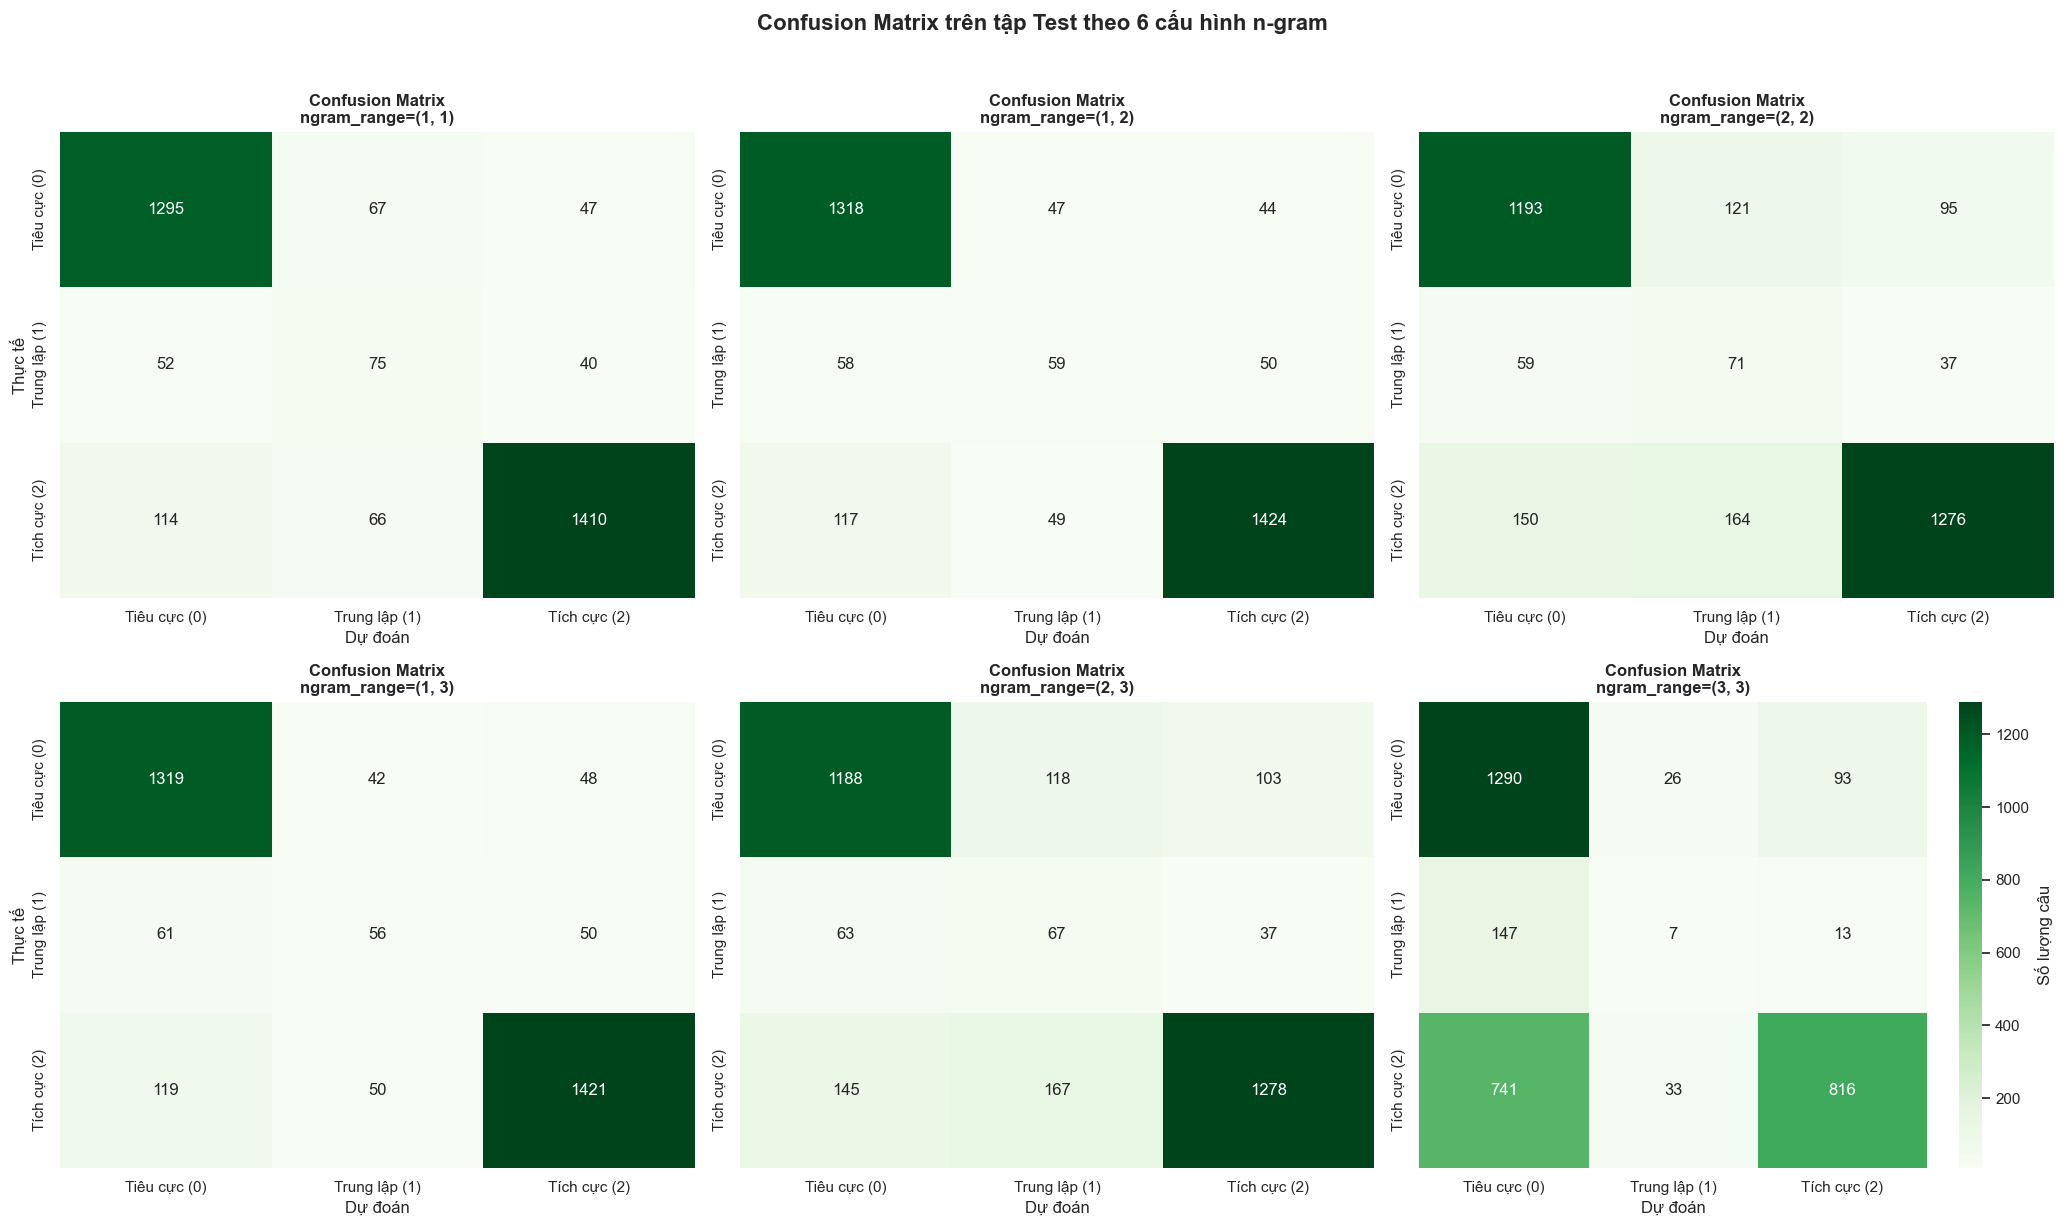

,ngram_range,recall_tieu_cuc,recall_trung_lap,recall_tich_cuc,precision_tieu_cuc,precision_trung_lap,precision_tich_cuc,nhầm nhiều nhất từ,nhầm nhiều nhất sang,số lượng nhầm nhiều nhất
0,"(1, 1)",0.9191,0.4491,0.8868,0.8864,0.3606,0.9419,Tích cực (2),Tiêu cực (0),114
1,"(1, 2)",0.9354,0.3533,0.8956,0.8828,0.3806,0.9381,Tích cực (2),Tiêu cực (0),117
2,"(2, 2)",0.8467,0.4251,0.8025,0.8509,0.1994,0.9062,Tích cực (2),Trung lập (1),164
3,"(1, 3)",0.9361,0.3353,0.8937,0.8799,0.3784,0.9355,Tích cực (2),Tiêu cực (0),119
4,"(2, 3)",0.8432,0.4012,0.8038,0.8510,0.1903,0.9013,Tích cực (2),Trung lập (1),167
5,"(3, 3)",0.9155,0.0419,0.5132,0.5923,0.1061,0.8850,Tích cực (2),Tiêu cực (0),741


In [23]:
# =========================================================
# CONFUSION MATRIX TRÊN TEST SET CHO 6 N-GRAM
# =========================================================
ngram_keys = [
    str(ngram_range)
    for ngram_range in ngram_ranges
    if str(ngram_range) in grid_search_by_ngram
]

n_cols = 3
n_rows = int(np.ceil(len(ngram_keys) / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(7 * n_cols, 6 * n_rows)
)

axes = np.array(axes).reshape(-1)

confusion_analysis_rows = []

for idx, ngram_key in enumerate(ngram_keys):
    result = grid_search_by_ngram[ngram_key]
    y_test_pred = result['y_test_pred']

    cm = confusion_matrix(y_test, y_test_pred, labels=label_order)

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Greens',
        xticklabels=target_names,
        yticklabels=target_names,
        ax=axes[idx],
        cbar=(idx == len(ngram_keys) - 1),
        cbar_kws={'label': 'Số lượng câu'}
    )

    axes[idx].set_title(
        f"Confusion Matrix\nngram_range={ngram_key}",
        fontweight='bold'
    )

    axes[idx].set_xlabel('Dự đoán')
    axes[idx].set_ylabel('Thực tế' if idx % 3 == 0 else '')

    row_sums = cm.sum(axis=1)
    col_sums = cm.sum(axis=0)

    per_class_recall = np.divide(
        np.diag(cm),
        row_sums,
        out=np.zeros_like(np.diag(cm), dtype=float),
        where=row_sums != 0
    )

    per_class_precision = np.divide(
        np.diag(cm),
        col_sums,
        out=np.zeros_like(np.diag(cm), dtype=float),
        where=col_sums != 0
    )

    off_diag = cm.copy()
    np.fill_diagonal(off_diag, 0)
    max_error_idx = np.unravel_index(np.argmax(off_diag), off_diag.shape)

    confusion_analysis_rows.append({
        'ngram_range': ngram_key,
        'recall_tieu_cuc': per_class_recall[0],
        'recall_trung_lap': per_class_recall[1],
        'recall_tich_cuc': per_class_recall[2],
        'precision_tieu_cuc': per_class_precision[0],
        'precision_trung_lap': per_class_precision[1],
        'precision_tich_cuc': per_class_precision[2],
        'nhầm nhiều nhất từ': target_names[max_error_idx[0]],
        'nhầm nhiều nhất sang': target_names[max_error_idx[1]],
        'số lượng nhầm nhiều nhất': off_diag[max_error_idx]
    })

for empty_idx in range(len(ngram_keys), len(axes)):
    axes[empty_idx].axis('off')

plt.suptitle(
    "Confusion Matrix trên tập Test theo 6 cấu hình n-gram",
    fontsize=16,
    fontweight='bold',
    y=1.02
)

plt.tight_layout()
plt.show()

confusion_analysis_df = pd.DataFrame(confusion_analysis_rows)

display(
    confusion_analysis_df.style.format({
        'recall_tieu_cuc': '{:.4f}',
        'recall_trung_lap': '{:.4f}',
        'recall_tich_cuc': '{:.4f}',
        'precision_tieu_cuc': '{:.4f}',
        'precision_trung_lap': '{:.4f}',
        'precision_tich_cuc': '{:.4f}'
    })
)

In [24]:
for _, row in confusion_analysis_df.iterrows():
    display(Markdown(f"""
#### Phân tích confusion matrix cho `ngram_range={row['ngram_range']}`

- Recall lớp Tiêu cực: **{row['recall_tieu_cuc']:.4f}**.
- Recall lớp Trung lập: **{row['recall_trung_lap']:.4f}**.
- Recall lớp Tích cực: **{row['recall_tich_cuc']:.4f}**.
- Cặp nhầm lẫn lớn nhất là từ **{row['nhầm nhiều nhất từ']}** sang **{row['nhầm nhiều nhất sang']}**, với **{int(row['số lượng nhầm nhiều nhất'])}** câu.

Nếu recall của lớp Trung lập thấp hơn rõ rệt so với hai lớp còn lại, điều này cho thấy mô hình vẫn gặp khó khăn với lớp thiểu số. Đây là hiện tượng phù hợp với đặc điểm của UIT-VSFC vì nhãn Neutral chỉ chiếm tỷ lệ nhỏ trong corpus.
"""))


#### Phân tích confusion matrix cho `ngram_range=(1, 1)`

- Recall lớp Tiêu cực: **0.9191**.
- Recall lớp Trung lập: **0.4491**.
- Recall lớp Tích cực: **0.8868**.
- Cặp nhầm lẫn lớn nhất là từ **Tích cực (2)** sang **Tiêu cực (0)**, với **114** câu.

Nếu recall của lớp Trung lập thấp hơn rõ rệt so với hai lớp còn lại, điều này cho thấy mô hình vẫn gặp khó khăn với lớp thiểu số. Đây là hiện tượng phù hợp với đặc điểm của UIT-VSFC vì nhãn Neutral chỉ chiếm tỷ lệ nhỏ trong corpus.



#### Phân tích confusion matrix cho `ngram_range=(1, 2)`

- Recall lớp Tiêu cực: **0.9354**.
- Recall lớp Trung lập: **0.3533**.
- Recall lớp Tích cực: **0.8956**.
- Cặp nhầm lẫn lớn nhất là từ **Tích cực (2)** sang **Tiêu cực (0)**, với **117** câu.

Nếu recall của lớp Trung lập thấp hơn rõ rệt so với hai lớp còn lại, điều này cho thấy mô hình vẫn gặp khó khăn với lớp thiểu số. Đây là hiện tượng phù hợp với đặc điểm của UIT-VSFC vì nhãn Neutral chỉ chiếm tỷ lệ nhỏ trong corpus.



#### Phân tích confusion matrix cho `ngram_range=(2, 2)`

- Recall lớp Tiêu cực: **0.8467**.
- Recall lớp Trung lập: **0.4251**.
- Recall lớp Tích cực: **0.8025**.
- Cặp nhầm lẫn lớn nhất là từ **Tích cực (2)** sang **Trung lập (1)**, với **164** câu.

Nếu recall của lớp Trung lập thấp hơn rõ rệt so với hai lớp còn lại, điều này cho thấy mô hình vẫn gặp khó khăn với lớp thiểu số. Đây là hiện tượng phù hợp với đặc điểm của UIT-VSFC vì nhãn Neutral chỉ chiếm tỷ lệ nhỏ trong corpus.



#### Phân tích confusion matrix cho `ngram_range=(1, 3)`

- Recall lớp Tiêu cực: **0.9361**.
- Recall lớp Trung lập: **0.3353**.
- Recall lớp Tích cực: **0.8937**.
- Cặp nhầm lẫn lớn nhất là từ **Tích cực (2)** sang **Tiêu cực (0)**, với **119** câu.

Nếu recall của lớp Trung lập thấp hơn rõ rệt so với hai lớp còn lại, điều này cho thấy mô hình vẫn gặp khó khăn với lớp thiểu số. Đây là hiện tượng phù hợp với đặc điểm của UIT-VSFC vì nhãn Neutral chỉ chiếm tỷ lệ nhỏ trong corpus.



#### Phân tích confusion matrix cho `ngram_range=(2, 3)`

- Recall lớp Tiêu cực: **0.8432**.
- Recall lớp Trung lập: **0.4012**.
- Recall lớp Tích cực: **0.8038**.
- Cặp nhầm lẫn lớn nhất là từ **Tích cực (2)** sang **Trung lập (1)**, với **167** câu.

Nếu recall của lớp Trung lập thấp hơn rõ rệt so với hai lớp còn lại, điều này cho thấy mô hình vẫn gặp khó khăn với lớp thiểu số. Đây là hiện tượng phù hợp với đặc điểm của UIT-VSFC vì nhãn Neutral chỉ chiếm tỷ lệ nhỏ trong corpus.



#### Phân tích confusion matrix cho `ngram_range=(3, 3)`

- Recall lớp Tiêu cực: **0.9155**.
- Recall lớp Trung lập: **0.0419**.
- Recall lớp Tích cực: **0.5132**.
- Cặp nhầm lẫn lớn nhất là từ **Tích cực (2)** sang **Tiêu cực (0)**, với **741** câu.

Nếu recall của lớp Trung lập thấp hơn rõ rệt so với hai lớp còn lại, điều này cho thấy mô hình vẫn gặp khó khăn với lớp thiểu số. Đây là hiện tượng phù hợp với đặc điểm của UIT-VSFC vì nhãn Neutral chỉ chiếm tỷ lệ nhỏ trong corpus.


### Phân tích heatmap tối ưu tham số

Heatmap biểu diễn Macro F1 trung bình qua 5-fold cross-validation theo từng cặp \((max\_df,C)\).

- \(C\) điều khiển mức phạt lỗi trong SVM. \(C\) càng lớn, mô hình càng cố gắng phân loại đúng dữ liệu huấn luyện, nhưng có thể tăng nguy cơ overfitting.
- \(max\_df\) càng thấp thì càng loại bỏ nhiều đặc trưng quá phổ biến.

Khu vực điểm cao quanh \(C=0.2\) và \(max\_df=0.2\) cho thấy dữ liệu này cần một mức regularization tương đối mạnh và cần lọc bớt từ phổ biến. Điều này phù hợp với đặc trưng phản hồi sinh viên: nhiều câu có các từ chung như “thầy”, “cô”, “môn”, “học”, nhưng các từ này không luôn quyết định cảm xúc.

### Phân tích confusion matrix

Confusion matrix cho biết mô hình nhầm giữa các lớp nào. Với bài toán mất cân bằng, cần đặc biệt quan sát hàng/cột của nhãn Trung lập.

Nếu nhiều câu Trung lập bị dự đoán thành Tiêu cực hoặc Tích cực, Macro F1 sẽ giảm mạnh vì lớp Trung lập có trọng số ngang với hai lớp còn lại trong công thức Macro F1. Trong khi đó, Accuracy vẫn có thể khá cao do hai lớp Tiêu cực và Tích cực chiếm phần lớn dữ liệu.

Vì vậy, confusion matrix giúp giải thích vì sao Accuracy đạt 85.03% nhưng Macro F1 chỉ đạt 70.18%.

In [25]:
# CẤU HÌNH NHÃN VÀ THỨ TỰ CHO BÁO CÁO PHÂN LOẠI
sentiment_mapping = {
    0: 'Tiêu cực',
    1: 'Trung lập',
    2: 'Tích cực'
}

label_order = [0, 1, 2]
target_names = ['Tiêu cực (0)', 'Trung lập (1)', 'Tích cực (2)']

In [26]:
# KIỂM TRA CÁC BIẾN BẮT BUỘC ĐÃ CÓ CHƯA
required_vars = [
    'grid_search_by_ngram',
    'df_train',
    'df_val',
    'df_test',
    'y_test'
]

missing_vars = [var for var in required_vars if var not in globals()]

if missing_vars:
    raise NameError(
        "Các biến sau chưa được khai báo, bạn cần chạy các cell phía trên trước: "
        + ", ".join(missing_vars)
    )

In [27]:
# CHỌN CÁC NGRAM MUỐN SO SÁNH
ngram_specs = [
    (1, 1),
    (1, 2),
    (2, 2),
    (1, 3),
    (2, 3),
    (3, 3)
]

def get_ngram_key(ngram_tuple):
    """
    Hàm lấy key tương ứng trong grid_search_by_ngram.
    """
    if str(ngram_tuple) in grid_search_by_ngram:
        return str(ngram_tuple)
    
    if ngram_tuple in grid_search_by_ngram:
        return ngram_tuple
    
    raise KeyError(
        f"Không tìm thấy kết quả cho ngram_range={ngram_tuple}. "
        f"Các key hiện có là: {list(grid_search_by_ngram.keys())}"
    )

# Chỉ lấy những ngram thực sự đã được train
available_ngram_specs = []

for ngram_tuple in ngram_specs:
    try:
        get_ngram_key(ngram_tuple)
        available_ngram_specs.append(ngram_tuple)
    except KeyError as e:
        print(f"Bỏ qua {ngram_tuple}: {e}")

if len(available_ngram_specs) == 0:
    raise ValueError("Không có ngram_range nào trong ngram_specs đã được train.")


In [28]:
# TẠO BẢNG SO SÁNH DỰ ĐOÁN TRÊN TẬP TEST
y_test_series = pd.Series(y_test).reset_index(drop=True)

comparison_error_df = pd.DataFrame({
    'Câu phản hồi gốc': df_test['sentence'].reset_index(drop=True),
    'Nhãn thực tế': y_test_series.map(sentiment_mapping)
})

wrong_summary_rows = []

for ngram_tuple in available_ngram_specs:
    ngram_key = get_ngram_key(ngram_tuple)
    result = grid_search_by_ngram[ngram_key]
    
    y_pred_series = pd.Series(result['y_test_pred']).reset_index(drop=True)
    y_pred_label = y_pred_series.map(sentiment_mapping)
    
    pred_col = f'Nhãn dự đoán {ngram_tuple}'
    comparison_error_df[pred_col] = y_pred_label
    
    wrong_count = (y_test_series != y_pred_series).sum()
    correct_count = len(y_test_series) - wrong_count
    total_count = len(y_test_series)
    
    wrong_summary_rows.append({
        'ngram_range': str(ngram_tuple),
        'Số câu dự đoán đúng': correct_count,
        'Số câu dự đoán sai': wrong_count,
        'Tổng số câu test': total_count,
        'Accuracy (%)': correct_count / total_count * 100,
        'Tỷ lệ sai (%)': wrong_count / total_count * 100
    })

wrong_summary_df = pd.DataFrame(wrong_summary_rows)

In [29]:
# TẠO BẢNG CHỈ GỒM CÁC CÂU CÓ ÍT NHẤT 1 NGRAM DỰ ĐOÁN SAI
pred_cols = [
    f'Nhãn dự đoán {ngram_tuple}'
    for ngram_tuple in available_ngram_specs
]

wrong_any_mask = comparison_error_df[pred_cols].ne(
    comparison_error_df['Nhãn thực tế'],
    axis=0
).any(axis=1)

wrong_predictions_comparison_df = comparison_error_df[wrong_any_mask].copy()

In [30]:
# HIỂN THỊ KẾT QUẢ 
print("TỔNG SỐ CÂU DỰ ĐOÁN SAI THEO TỪNG NGRAM_RANGE")
display(
    wrong_summary_df.style.format({
        'Accuracy (%)': '{:.2f}',
        'Tỷ lệ sai (%)': '{:.2f}'
    })
)

print("BẢNG SO SÁNH TOÀN BỘ DỰ ĐOÁN TRÊN TẬP TEST")
display(comparison_error_df)
print("BẢNG SO SÁNH CÁC CÂU DỰ ĐOÁN SAI")
display(wrong_predictions_comparison_df)

TỔNG SỐ CÂU DỰ ĐOÁN SAI THEO TỪNG NGRAM_RANGE


,ngram_range,Số câu dự đoán đúng,Số câu dự đoán sai,Tổng số câu test,Accuracy (%),Tỷ lệ sai (%)
0,"(1, 1)",2780,386,3166,87.81,12.19
1,"(1, 2)",2801,365,3166,88.47,11.53
2,"(2, 2)",2540,626,3166,80.23,19.77
3,"(1, 3)",2796,370,3166,88.31,11.69
4,"(2, 3)",2533,633,3166,80.01,19.99
5,"(3, 3)",2113,1053,3166,66.74,33.26


BẢNG SO SÁNH TOÀN BỘ DỰ ĐOÁN TRÊN TẬP TEST


,Câu phản hồi gốc,Nhãn thực tế,"Nhãn dự đoán (1, 1)","Nhãn dự đoán (1, 2)","Nhãn dự đoán (2, 2)","Nhãn dự đoán (1, 3)","Nhãn dự đoán (2, 3)","Nhãn dự đoán (3, 3)"
0,nói tiếng anh lưu loát .,Tích cực,Trung lập,Tích cực,Tích cực,Tích cực,Tích cực,Tiêu cực
1,giáo viên rất vui tính .,Tích cực,Tích cực,Tích cực,Tích cực,Tích cực,Tích cực,Tiêu cực
2,cô max có tâm .,Tích cực,Tích cực,Tích cực,Tích cực,Tích cực,Tích cực,Tiêu cực
3,"giảng bài thu hút , dí dỏm .",Tích cực,Tích cực,Tích cực,Trung lập,Tích cực,Trung lập,Tiêu cực
4,"giáo viên không giảng dạy kiến thức , hướng dẫ...",Tiêu cực,Tiêu cực,Tiêu cực,Tiêu cực,Tiêu cực,Tiêu cực,Trung lập
...,...,...,...,...,...,...,...,...
3161,"các slide khó hiểu , ngôn ngữ trong slide phức...",Tiêu cực,Tiêu cực,Tiêu cực,Tiêu cực,Tiêu cực,Tiêu cực,Tiêu cực
3162,giáo viên giảng dạy có tâm huyết .,Tích cực,Tích cực,Tích cực,Tích cực,Tích cực,Tích cực,Tiêu cực
3163,chia sẻ cho em nhiều điều hay .,Tích cực,Tích cực,Tích cực,Tích cực,Tích cực,Tích cực,Tiêu cực
3164,em tiếp thu chậm .,Tiêu cực,Tiêu cực,Tích cực,Tích cực,Tích cực,Tích cực,Tiêu cực


BẢNG SO SÁNH CÁC CÂU DỰ ĐOÁN SAI


,Câu phản hồi gốc,Nhãn thực tế,"Nhãn dự đoán (1, 1)","Nhãn dự đoán (1, 2)","Nhãn dự đoán (2, 2)","Nhãn dự đoán (1, 3)","Nhãn dự đoán (2, 3)","Nhãn dự đoán (3, 3)"
0,nói tiếng anh lưu loát .,Tích cực,Trung lập,Tích cực,Tích cực,Tích cực,Tích cực,Tiêu cực
1,giáo viên rất vui tính .,Tích cực,Tích cực,Tích cực,Tích cực,Tích cực,Tích cực,Tiêu cực
2,cô max có tâm .,Tích cực,Tích cực,Tích cực,Tích cực,Tích cực,Tích cực,Tiêu cực
3,"giảng bài thu hút , dí dỏm .",Tích cực,Tích cực,Tích cực,Trung lập,Tích cực,Trung lập,Tiêu cực
4,"giáo viên không giảng dạy kiến thức , hướng dẫ...",Tiêu cực,Tiêu cực,Tiêu cực,Tiêu cực,Tiêu cực,Tiêu cực,Trung lập
...,...,...,...,...,...,...,...,...
3157,"thầy dạy đầy đủ , nhiệt tình .",Tích cực,Tích cực,Tích cực,Tích cực,Tích cực,Tích cực,Tiêu cực
3162,giáo viên giảng dạy có tâm huyết .,Tích cực,Tích cực,Tích cực,Tích cực,Tích cực,Tích cực,Tiêu cực
3163,chia sẻ cho em nhiều điều hay .,Tích cực,Tích cực,Tích cực,Tích cực,Tích cực,Tích cực,Tiêu cực
3164,em tiếp thu chậm .,Tiêu cực,Tiêu cực,Tích cực,Tích cực,Tích cực,Tích cực,Tiêu cực


In [31]:
# TẠO THÊM CÁC BẢNG DATASET GỐC ĐỂ XUẤT RA EXCEL
def prepare_dataset_for_export(df, set_name):
    export_df = df.copy()
    
    if 'set' not in export_df.columns:
        export_df['set'] = set_name
    
    export_df['sentiment_label'] = export_df['sentiment'].map(sentiment_mapping)
    
    return export_df

train_export_df = prepare_dataset_for_export(df_train, 'Train')
val_export_df = prepare_dataset_for_export(df_val, 'Validation')
test_export_df = prepare_dataset_for_export(df_test, 'Test')

all_dataset_export_df = pd.concat(
    [train_export_df, val_export_df, test_export_df],
    ignore_index=True
)

# Bảng export có thêm cột đúng/sai cho từng ngram
export_comparison_df = comparison_error_df.copy()

for ngram_tuple in available_ngram_specs:
    pred_col = f'Nhãn dự đoán {ngram_tuple}'
    correct_col = f'Dự đoán đúng {ngram_tuple}'
    
    export_comparison_df[correct_col] = (
        export_comparison_df[pred_col] == export_comparison_df['Nhãn thực tế']
    )

In [32]:
# XUẤT RA FILE EXCEL TRONG THƯ MỤC DATASET
output_dir = dataset_dir if 'dataset_dir' in globals() else '../dataset'
os.makedirs(output_dir, exist_ok=True)

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
output_path = os.path.join(
    output_dir,
    f"sentiment_ngram_full_report_{timestamp}.xlsx"
)

with pd.ExcelWriter(output_path, engine="openpyxl") as writer:
    
    wrong_summary_df.to_excel(
        writer,
        sheet_name="wrong_summary",
        index=False
    )
    
    export_comparison_df.to_excel(
        writer,
        sheet_name="all_test_predictions",
        index=False
    )

    wrong_predictions_comparison_df.to_excel(
        writer,
        sheet_name="wrong_any_ngram",
        index=False
    )

    for ngram_tuple in available_ngram_specs:
        pred_col = f'Nhãn dự đoán {ngram_tuple}'
        
        wrong_one_ngram_df = comparison_error_df[
            comparison_error_df[pred_col] != comparison_error_df['Nhãn thực tế']
        ].copy()
        
        sheet_name = f"wrong_{ngram_tuple[0]}_{ngram_tuple[1]}"
        
        wrong_one_ngram_df.to_excel(
            writer,
            sheet_name=sheet_name,
            index=False
        )

    train_export_df.to_excel(
        writer,
        sheet_name="train_dataset",
        index=False
    )
    
    val_export_df.to_excel(
        writer,
        sheet_name="validation_dataset",
        index=False
    )
    
    test_export_df.to_excel(
        writer,
        sheet_name="test_dataset",
        index=False
    )
    
    all_dataset_export_df.to_excel(
        writer,
        sheet_name="all_original_dataset",
        index=False
    )

print("ĐÃ XUẤT FILE EXCEL THÀNH CÔNG")
print(output_path)

ĐÃ XUẤT FILE EXCEL THÀNH CÔNG
../dataset\sentiment_ngram_full_report_20260526_131218.xlsx


## Tổng kết kết quả và đối chiếu với bài báo gốc

### 1. Kết quả chính của mô hình SVM trong notebook

Notebook huấn luyện Linear SVM trên đặc trưng TF-IDF với 6 cấu hình n-gram:

- `ngram_range=(1,1)`
- `ngram_range=(1,2)`
- `ngram_range=(2,2)`
- `ngram_range=(1,3)`
- `ngram_range=(2,3)`
- `ngram_range=(3,3)`

Pipeline tổng quát:

$$
\text{Word Segmentation}
\rightarrow
\text{TF-IDF n-gram}
\rightarrow
\text{Linear SVM}
$$

Bộ tham số tốt nhất được chọn bằng GridSearchCV với tiêu chí `f1_macro`. Do đó, kết quả cần được đọc theo hướng ưu tiên cân bằng hiệu năng giữa các lớp, thay vì chỉ tối đa hóa Accuracy.

### 2. Ý nghĩa của Macro F1 trong bài toán này

Với từng lớp \(c\):

$$
Precision_c
=
\frac{TP_c}{TP_c+FP_c},
$$

$$
Recall_c
=
\frac{TP_c}{TP_c+FN_c},
$$

$$
F1_c
=
\frac{2Precision_cRecall_c}{Precision_c+Recall_c}.
$$

Macro F1 được tính bằng:

$$
MacroF1
=
\frac{1}{K}
\sum_{c=1}^{K}
F1_c.
$$

Vì mỗi lớp có trọng số ngang nhau, Macro F1 phù hợp hơn Accuracy khi dữ liệu mất cân bằng.

### 3. So sánh với bài báo gốc

Bài báo gốc dùng Naive Bayes và Maximum Entropy, đồng thời dùng đặc trưng n-gram dạng bigram trong baseline. Kết quả MaxEnt cho sentiment task đạt Average F1-score 87.94%.

Tuy nhiên, cần lưu ý rằng trong Table IX của bài báo, F1 theo từng lớp là:

$$
F1_{Positive}=91.32,
\quad
F1_{Negative}=90.52,
\quad
F1_{Neutral}=33.99.
$$

Nếu tính Macro F1 thật sự:

$$
MacroF1_{MaxEnt}
=
\frac{91.32+90.52+33.99}{3}
\approx
71.94.
$$

Do đó, con số Average F1-score 87.94% trong bài báo nhiều khả năng là trung bình có trọng số theo số mẫu, không phải Macro F1. Vì vậy, không nên so sánh trực tiếp Macro F1 của notebook với Average F1 trong bài báo nếu chưa thống nhất cách tính.

### 4. Vì sao SVM có thể không vượt trội hơn MaxEnt trong bài báo?

Có một số nguyên nhân hợp lý:

1. **Khác biệt hàm mất mát.**  
   MaxEnt là mô hình log-linear tối ưu xác suất hậu nghiệm:

   $$
   P(y=c|\mathbf{x})
   =
   \frac{
   \exp(\mathbf{w}_c^T\mathbf{x}+b_c)
   }{
   \sum_k \exp(\mathbf{w}_k^T\mathbf{x}+b_k)
   }.
   $$

   Trong khi đó, Linear SVM tối ưu hinge loss:

   $$
   \mathcal{L}_{SVM}
   =
   \sum_{i=1}^{N}
   \max(0,1-y_if(\mathbf{x}_i)).
   $$

   Hai hàm mất mát có cách xử lý điểm gần biên khác nhau, nên kết quả có thể khác nhau trên các câu mơ hồ.

2. **Khác biệt tiền xử lý.**  
   Bài báo mô tả việc chuẩn hóa dữ liệu gồm tách câu, thay thế viết tắt, sửa lỗi chính tả và ẩn danh tên riêng. Notebook hiện tại chủ yếu dùng `underthesea.word_tokenize`, nên tập đặc trưng TF-IDF có thể khác so với baseline gốc.

3. **Mất cân bằng lớp Trung lập.**  
   Nhãn Trung lập có rất ít dữ liệu, làm cho mô hình khó học ranh giới ổn định. Đây là nguyên nhân khiến Macro F1 thấp hơn Accuracy.

4. **Khác biệt mục tiêu tối ưu.**  
   Notebook dùng `scoring='f1_macro'`, còn bài báo báo cáo Average F1. Nếu Average F1 là weighted average, hai chỉ số này không phản ánh cùng một mục tiêu.

### 5. Kết luận

Khi mở rộng từ 3 lên 6 cấu hình n-gram, kết luận nên dựa trên đồng thời:

- bảng `comparison_df`;
- learning curve Accuracy;
- learning curve Macro F1;
- heatmap tối ưu tham số;
- confusion matrix;
- bảng phân tích lỗi theo từng n-gram.

Cấu hình tốt nhất không nhất thiết là cấu hình có n-gram dài nhất. Với dữ liệu phản hồi ngắn như UIT-VSFC, trigram có thể bổ sung ngữ cảnh nhưng cũng làm tăng độ thưa của không gian đặc trưng.

### Phân tích các câu dự đoán sai

Notebook ghi nhận 474 câu dự đoán sai trên 3.166 câu Test. Các mẫu lỗi hiển thị cho thấy một số kiểu khó thường gặp:

1. **Câu ngắn nhưng hàm ý mạnh:** câu ngắn có ít đặc trưng TF-IDF, nên mô hình dễ thiếu tín hiệu.
2. **Câu có từ tích cực nhưng ngữ cảnh tiêu cực:** ví dụ một câu có từ “tích cực” nhưng toàn câu lại phàn nàn hoặc phủ định.
3. **Câu Trung lập bị kéo về hai cực:** nếu câu Trung lập chứa một vài từ thường xuất hiện trong lớp Tích cực hoặc Tiêu cực, SVM có thể đẩy câu đó qua ranh giới phân loại.
4. **Câu cần hiểu ngữ cảnh:** các mô hình TF-IDF tuyến tính không hiểu sâu quan hệ ngữ nghĩa, phủ định dài hoặc mỉa mai như các mô hình ngôn ngữ hiện đại.

Do đó, phân tích lỗi là bước quan trọng để xác định liệu cần cải thiện tiền xử lý, thay đổi mô hình, hay điều chỉnh cách đánh giá.

## Tổng kết kết quả và đối chiếu với bài báo gốc

### 1. Kết quả chính của mô hình SVM trong notebook

Pipeline đang sử dụng:
$
[
\text{Word Segmentation}
\rightarrow
\text{TF-IDF } ngram\_range=(1,2)
\rightarrow
\text{Linear SVM}.
\]
$
Kết quả GridSearchCV:

\[
C=0.2,\quad max\_df=0.2,\quad CV\ MacroF1=71.01\%.
\]

Kết quả trên tập Test:

\[
Accuracy=85.03\%,
\quad
MacroF1=70.18\%.
\]

Theo từng lớp:

| Lớp | Precision | Recall | F1-score | Support |
|---|---:|---:|---:|---:|
| Tiêu cực | 0.86 | 0.90 | 0.88 | 1409 |
| Trung lập | 0.29 | 0.40 | 0.34 | 167 |
| Tích cực | 0.92 | 0.86 | 0.89 | 1590 |

Mô hình dự đoán sai 474 / 3166 câu, tương ứng tỷ lệ sai:

\[
\frac{474}{3166}\times100\approx14.97\%.
\]

### 2. Vì sao Tiêu cực và Tích cực cao hơn Trung lập?

Các lớp Tiêu cực và Tích cực có nhiều mẫu hơn và thường có tín hiệu từ vựng rõ hơn. Ví dụ, các từ/cụm như “nhiệt tình”, “hay”, “tận tâm” thường nghiêng về Tích cực; các từ/cụm như “khó hiểu”, “sơ sài”, “buồn ngủ”, “quá nhanh” thường nghiêng về Tiêu cực.

Với Linear SVM:

\[
f(\mathbf{x})=\mathbf{w}^{T}\mathbf{x}+b.
\]

Nếu một đặc trưng \(x_j\) thường xuất hiện trong lớp Tích cực, hệ số \(w_j\) có thể được học theo hướng làm tăng điểm cho lớp Tích cực. Ngược lại, đặc trưng nghiêng về Tiêu cực sẽ kéo điểm quyết định về phía lớp Tiêu cực.

Nhãn Trung lập khó hơn vì:
- chỉ có 167 mẫu trong Test;
- nhiều câu không có từ khóa cảm xúc mạnh;
- một số câu có cả tín hiệu khen và chê;
- ranh giới giữa “trung lập” và “cảm xúc nhẹ” không rõ ràng.

Vì vậy, F1-score của Trung lập thấp là kết quả hợp lý về mặt thống kê, không nhất thiết là lỗi cài đặt.

### 3. So sánh với bài báo gốc cần rất cẩn thận

Bài báo gốc báo cáo MaxEnt đạt “Average F1-score” 87.94% cho sentiment task. Tuy nhiên, trong Table IX, F1 theo từng lớp là:

\[
F1_{Positive}=91.32,\quad
F1_{Negative}=90.52,\quad
F1_{Neutral}=33.99.
\]

Nếu tính Macro F1 thật sự:

\[
MacroF1_{MaxEnt}
=
\frac{91.32+90.52+33.99}{3}
\approx71.94\%.
\]

Con số này khác với 87.94%. Nếu dùng phân phối test gần với notebook hiện tại:

\[
N_{Positive}=1590,\quad N_{Negative}=1409,\quad N_{Neutral}=167,
\]

thì Weighted F1 xấp xỉ:

\[
WeightedF1
=
\frac{1590\cdot91.32+1409\cdot90.52+167\cdot33.99}{3166}
\approx87.94\%.
\]

Do đó, “Average F1-score” trong bài báo nhiều khả năng là trung bình có trọng số theo số mẫu, không phải Macro F1. Vì vậy, không nên so sánh trực tiếp:

\[
MacroF1_{\text{SVM notebook}}
\quad \text{với} \quad
AverageF1_{\text{MaxEnt paper}}.
\]

### 4. Vì sao SVM trong notebook có thể không nổi trội như MaxEnt của bài báo?

Nếu so sánh theo chỉ số mà bài báo báo cáo, SVM trong notebook có Weighted F1 khoảng 0.86, thấp hơn Average F1 0.8794 của MaxEnt. Một số nguyên nhân hợp lý:

#### a. Khác biệt thuật toán tối ưu

Maximum Entropy là mô hình log-linear:

\[
P(y=c|\mathbf{x})
=
\frac{\exp(\mathbf{w}_c^{T}\mathbf{x}+b_c)}
{\sum_k \exp(\mathbf{w}_k^{T}\mathbf{x}+b_k)}.
\]

Hàm mất mát thường là negative log-likelihood:

\[
\mathcal{L}_{MaxEnt}
=
-\sum_{i=1}^{N}\log P(y_i|\mathbf{x}_i).
\]

Trong khi đó, SVM tối ưu hinge loss:
$
\[
\mathcal{L}_{SVM}
=
\sum_{i=1}^{N}\max(0,1-y_if(\mathbf{x}_i)).
\]
$
Logistic loss của MaxEnt vẫn phạt các điểm dự đoán đúng nhưng chưa đủ tự tin, còn hinge loss của SVM không phạt thêm khi điểm đã nằm ngoài margin. Với dữ liệu có nhiều câu mơ hồ, hai hàm mất mát có thể dẫn đến ranh giới phân loại khác nhau.

#### b. Khác biệt tiền xử lý

Bài báo gốc mô tả các bước chuẩn hóa như thay thế từ viết tắt, sửa lỗi chính tả và ẩn danh tên riêng. Notebook này dùng `underthesea.word_tokenize` trên các câu hiện có. Khác biệt tokenizer và chuẩn hóa có thể tạo ra tập đặc trưng TF-IDF khác so với bài báo.

#### c. Mất cân bằng lớp Trung lập

Notebook dùng `class_weight='balanced'`, giúp tăng trọng số cho lớp Trung lập. Điều này có thể cải thiện sự công bằng giữa các lớp nhưng cũng có thể làm giảm Accuracy hoặc Weighted F1 nếu mô hình dự đoán Trung lập nhiều hơn cần thiết. Đây là đánh đổi thường gặp giữa Macro F1 và Accuracy.

#### d. Chỉ số đánh giá khác nhau

SVM trong notebook được tối ưu bằng `scoring='f1_macro'`, nghĩa là ưu tiên cân bằng giữa các lớp. Trong khi đó, chỉ số “Average F1-score” của bài báo nhiều khả năng là weighted average. Hai mục tiêu này không hoàn toàn giống nhau.

### 5. Kết luận

Có thể rút ra các kết luận sau:

1. Linear SVM + TF-IDF đạt kết quả tốt trên hai lớp lớn: Tiêu cực và Tích cực.
2. Nhãn Trung lập là nguồn lỗi chính vì dữ liệu ít và ranh giới ngữ nghĩa mơ hồ.
3. Test Macro F1 = 70.18% phản ánh rõ hạn chế ở lớp Trung lập hơn Accuracy = 85.03%.
4. Không nên kết luận SVM kém hơn MaxEnt nếu chưa thống nhất cách tính F1. Khi quy đổi Table IX của bài báo sang Macro F1, MaxEnt có Macro F1 xấp xỉ 71.94%, khá gần với SVM trong notebook.
5. Nếu mục tiêu là cải thiện kết quả tiếp theo, nên thử:
   - so sánh nhiều cấu hình `ngram_range`;
   - chuẩn hóa viết tắt/lỗi chính tả giống bài báo hơn;
   - thử Logistic Regression/MaxEnt để đối chiếu trực tiếp;
   - dùng thêm phân tích lỗi cho nhãn Trung lập.

### 6. Tài liệu tham khảo

[1] K. V. Nguyen, V. D. Nguyen, P. X. V. Nguyen, T. T. H. Truong, and N. L.-T. Nguyen, “UIT-VSFC: Vietnamese Students’ Feedback Corpus for Sentiment Analysis,” KSE, 2018.

[2] T. Joachims, “Text Categorization with Support Vector Machines: Learning with Many Relevant Features,” ECML, 1998.

[3] scikit-learn documentation, `TfidfVectorizer`, `LinearSVC`, and class weighting.

**Tại sao nhãn tích cực và nhãn tiêu cực đạt độ chính xác cao ?**

- Trong tập Train, các từ khóa như "nhiệt tình", "hay", và "tận tâm" tập trung hầu hết ở nhãn tích cực. Ở chiều ngược lại, nhãn tiêu cực được định hình bởi các từ như "khó hiểu" hay "buồn ngủ". TF-IDF sẽ gán trọng số rất cao cho các từ mang tính đặc trưng này vì chúng xuất hiện nhiều trong một lớp nhưng lại hiếm ở các lớp khác. Trong không gian vector, các câu tích cực/tiêu cực sẽ tạo thành các cụm tách biệt hẳn nhau. Khi đó, Linear SVM chỉ cần thiết lập một siêu mặt phẳng $f(x) = \mathbf{w}^T \mathbf{x} + b$ với các hệ số $w_i$ cực lớn cho những từ khóa này là có thể phân loại đúng nhãn rất tốt.

**Tại sao nhãn trung lập thường bị dự đoán sai ?**

- Qua kiểm tra các mẫu trung lập như: "em nói điều này có thể hơi xúc phạm nhưng kỹ năng sư phạm của thầy cần được cải thiện..." hoặc "dù phương pháp... hiệu quả nhưng vẫn có chút nghi ngờ...". Một câu trung thực có thể là một câu phức chứa cả hai thái cực. Vector tổng hợp sẽ nằm lơ lửng ở giữa ranh giới, nơi mà chỉ cần một biến động nhỏ về hệ số $C$ của SVM cũng khiến mô hình đoán nhầm sang tích cực hoặc tiêu cực.

In [33]:
# =========================================================
# XUẤT JSON ĐẶC TRƯNG TF-IDF THEO TỪNG CÂU TRAIN
# Dùng đúng TF-IDF vectorizer đã fit trong best_model của từng n-gram
# Các trường: id, sentence, sentiment, 1_1, 1_2, 2_2, 1_3, 2_3, 3_3
# Quy tắc nhãn:
# 0 = Tiêu cực, 1 = Trung lập, 2 = Tích cực
# =========================================================

import os
import json
import numpy as np
import pandas as pd
from datetime import datetime
from IPython.display import display

if 'grid_search_by_ngram' not in globals():
    raise NameError(
        "Biến grid_search_by_ngram chưa tồn tại. "
        "Bạn cần chạy Cell train chính trước khi xuất JSON TF-IDF."
    )

# ---------------------------------------------------------
# 1. CẤU HÌNH DANH SÁCH N-GRAM CẦN XUẤT
# ---------------------------------------------------------
ngram_export_configs = {
    "1_1": "(1, 1)",
    "1_2": "(1, 2)",
    "2_2": "(2, 2)",
    "1_3": "(1, 3)",
    "2_3": "(2, 3)",
    "3_3": "(3, 3)"
}

# ---------------------------------------------------------
# 2. CHUẨN BỊ DỮ LIỆU TRAIN GỐC
# ---------------------------------------------------------
df_train_export = df_train.reset_index(drop=True).copy()

# Dùng đúng hàm preprocess_text như lúc train model
train_texts_segmented = df_train_export["sentence"].apply(preprocess_text)

json_records = []

for idx, row in df_train_export.iterrows():
    json_records.append({
        "id": int(idx),
        "sentence": str(row["sentence"]),
        "sentiment": int(row["sentiment"])
    })

# ---------------------------------------------------------
# 3. HÀM CHUYỂN VECTOR TF-IDF THÀNH CHUỖI ĐẶC TRƯNG
# ---------------------------------------------------------
def tfidf_row_to_feature_string(row_vector, feature_names, decimal_places=6):
    row_vector = row_vector.tocsr()
    
    indices = row_vector.indices
    scores = row_vector.data
    
    if len(scores) == 0:
        return ""
    
    sorted_order = np.argsort(scores)[::-1]
    
    feature_items = [
        f"{feature_names[indices[i]]}:{scores[i]:.{decimal_places}f}"
        for i in sorted_order
    ]
    
    return ", ".join(feature_items)

# ---------------------------------------------------------
# 4. LẤY TF-IDF TỪ BEST MODEL ĐÃ TRAIN
# ---------------------------------------------------------
ngram_summary_rows = []

for field_name, ngram_key in ngram_export_configs.items():
    if ngram_key not in grid_search_by_ngram:
        print(f"Bỏ qua {field_name}: chưa có model cho ngram_range={ngram_key}")
        continue
    
    print("=" * 80)
    print(f"Đang xuất TF-IDF theo best_model cho ngram_range={ngram_key} -> trường '{field_name}'")
    
    best_model = grid_search_by_ngram[ngram_key]['best_model']
    tfidf_vectorizer = best_model.named_steps['tfidf']
    
    X_tfidf = tfidf_vectorizer.transform(train_texts_segmented)
    feature_names = np.array(tfidf_vectorizer.get_feature_names_out())
    
    for row_idx in range(X_tfidf.shape[0]):
        json_records[row_idx][field_name] = tfidf_row_to_feature_string(
            X_tfidf[row_idx],
            feature_names,
            decimal_places=6
        )
    
    density = X_tfidf.nnz / (X_tfidf.shape[0] * X_tfidf.shape[1])
    
    best_params = grid_search_by_ngram[ngram_key]['grid_search'].best_params_
    
    ngram_summary_rows.append({
        "Trường JSON": field_name,
        "ngram_range": ngram_key,
        "best_max_df": best_params.get("tfidf__max_df"),
        "best_C": best_params.get("svm__C"),
        "Số câu": X_tfidf.shape[0],
        "Số đặc trưng": X_tfidf.shape[1],
        "Số giá trị TF-IDF khác 0": X_tfidf.nnz,
        "Mật độ ma trận (%)": density * 100
    })

# ---------------------------------------------------------
# 5. XUẤT FILE JSON
# ---------------------------------------------------------
output_dir = dataset_dir if 'dataset_dir' in globals() else "../dataset"
os.makedirs(output_dir, exist_ok=True)

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
output_json_path = os.path.join(
    output_dir,
    f"train_tfidf_ngram_features_from_best_model_{timestamp}.json"
)

with open(output_json_path, "w", encoding="utf-8") as f:
    json.dump(
        json_records,
        f,
        ensure_ascii=False,
        indent=2
    )

# ---------------------------------------------------------
# 6. HIỂN THỊ KIỂM TRA
# ---------------------------------------------------------
ngram_summary_df = pd.DataFrame(ngram_summary_rows)

print("ĐÃ XUẤT FILE JSON THÀNH CÔNG")
print(output_json_path)
print(f"Tổng số record đã xuất: {len(json_records)}")

display(
    ngram_summary_df.style.format({
        "best_max_df": "{:.2f}",
        "best_C": "{:.2f}",
        "Mật độ ma trận (%)": "{:.4f}"
    })
)

print("Xem thử 1 record đầu tiên:")
display(pd.DataFrame([json_records[0]]))

Đang xuất TF-IDF theo best_model cho ngram_range=(1, 1) -> trường '1_1'
Đang xuất TF-IDF theo best_model cho ngram_range=(1, 2) -> trường '1_2'
Đang xuất TF-IDF theo best_model cho ngram_range=(2, 2) -> trường '2_2'
Đang xuất TF-IDF theo best_model cho ngram_range=(1, 3) -> trường '1_3'
Đang xuất TF-IDF theo best_model cho ngram_range=(2, 3) -> trường '2_3'
Đang xuất TF-IDF theo best_model cho ngram_range=(3, 3) -> trường '3_3'
ĐÃ XUẤT FILE JSON THÀNH CÔNG
../dataset\train_tfidf_ngram_features_from_best_model_20260526_131241.json
Tổng số record đã xuất: 11426


,Trường JSON,ngram_range,best_max_df,best_C,Số câu,Số đặc trưng,Số giá trị TF-IDF khác 0,Mật độ ma trận (%)
0,1_1,"(1, 1)",0.20,0.20,11426,1248,92845,0.6511
1,1_2,"(1, 2)",0.20,0.20,11426,4969,146929,0.2588
2,2_2,"(2, 2)",0.10,0.40,11426,3721,54084,0.1272
3,1_3,"(1, 3)",0.20,0.20,11426,6402,160273,0.2191
4,2_3,"(2, 3)",0.10,0.60,11426,5154,67428,0.1145
5,3_3,"(3, 3)",0.10,0.20,11426,1433,13344,0.0815


Xem thử 1 record đầu tiên:


,id,sentence,sentiment,1_1,1_2,2_2,1_3,2_3,3_3
0,0,slide giáo trình đầy đủ .,2,"giáo_trình:0.650889, slide:0.537997, đầy_đủ:0....","giáo_trình:0.650889, slide:0.537997, đầy_đủ:0....",,"giáo_trình:0.650889, slide:0.537997, đầy_đủ:0....",,
